In [23]:
import numpy as np
theta=8.0
sigma=4.5
U1=np.random.uniform(0,1)
U2=np.random.uniform(0,1)
X1=np.sqrt(-2*np.log(U1))*np.sin(2*np.pi*U2)
X2 = np.sqrt(-2*np.log(U1))*np.cos(2 * np.pi*U2)
xi1=theta+sigma*X1
xi2=theta+sigma*X2
print(f"Сгенерированная пара случайных величин: {xi1, xi2}")
print([xi1, xi2])

Сгенерированная пара случайных величин: (4.175171116285277, 7.6805487650466455)
[4.175171116285277, 7.6805487650466455]


In [24]:
import numpy as np
a = 132
theta = 108
alpha = 1 - np.random.random() # α ∈ (0,1]
xi = int(np.ceil(a - 1 + theta * alpha))
print(f"Сгенерированная случайная величина: {xi}")

Сгенерированная случайная величина: 162


# <a id="title2">Домашнее задание 2. Основные понятия математической статистики</a>
**1) Генерация выборок выбранных случайных величин**  
а) Дискретное равномерное II  
Будем генерировать 5 выборок длины 1000, и разбивать каждую выборку на выборки длины 5, 10, 100, 200, 400, 600, 800, 1000.  
[Код генератора выборок](#Unigenerate)

б) Нормальное I  
Будем генерировать 5 выборок длины 1000, и разбивать каждую выборку на выборки длины 5, 10, 100, 200, 400, 600, 800, 1000.  
[Код генератора выборок](#Normalgenerate)

# <a id="Unigenerate"> Генерация выборок дискретного равномерного II распределения</a>

In [27]:
import numpy as np
a = 132
theta1 = 108

# Функция, которая возвращает список длины n из сгенерированных выборок длины 1000 дискретного равномерного распределения 
def Unigenerate1000(n):
    Uniar1000 = []
    for i in range(n):
        Uniar1000.append(list(np.ceil(a - 1 + theta1 * (1 - np.random.random(1000))).astype(int)))
    return Uniar1000
    
# Функция, которая разбивает каждую из выборок полученную из Unigenerate1000 на выборку длины length 
#(разбивка происходит от начала выборки длины 1000 до length) и возвращает список из полученных выборок длины length
def Unicut(Uniar1000, length):
    Uniarlength=[]
    for i in range(len(Uniar1000)):
        Uniarlength.append(Uniar1000[i][:length])
    return Uniarlength
    
Uniar1000 = Unigenerate1000(5)   # 5 выборок длины 1000
Uniar5 = Unicut(Uniar1000,5)     # 5 выборок длины 5
Uniar10 = Unicut(Uniar1000,10)   # 5 выборок длины 10
Uniar100 = Unicut(Uniar1000,100) # 5 выборок длины 100
Uniar200 = Unicut(Uniar1000,200) # 5 выборок длины 200
Uniar400 = Unicut(Uniar1000,400) # 5 выборок длины 400
Uniar600 = Unicut(Uniar1000,600) # 5 выборок длины 600
Uniar800 = Unicut(Uniar1000,800) # 5 выборок длины 800

# <a id="Normalgenerate"> Генерация выборок нормального I распределения</a>

In [29]:
import numpy as np
sigma = 4.5
theta2 = 8.0

# Функция, которая возвращает список длины n из сгенерированных выборок длины 1000 нормального распределения 
def Normalgenerate1000(n):
    Normal1000=[]
    eps = 1e-12 #чтобы не было log(0)
    for i in range(n):
        U1 = np.random.uniform(0, 1, size=500)
        U2 = np.random.uniform(0, 1, size=500)
        U1 = np.maximum(U1, eps)
        Normal1000.append(np.column_stack((theta2+sigma*(np.sqrt(-2*np.log(U1))*np.sin(2*np.pi*U2)), 
                                           theta2+sigma*(np.sqrt(-2*np.log(U1))*np.cos(2 * np.pi*U2)))).ravel().tolist())
    return Normal1000

# Функция, которая разбивает каждую из выборок полученную из Normalgenerate1000 на выборку длины length 
#(разбивка происходит от начала выборки длины 1000 до length) и возвращает список из полученных выборок длины length
def Normalcut(Normalar1000, length):
    Normalarlength=[]
    for i in range(len(Normalar1000)):
        Normalarlength.append(Normalar1000[i][:length])
    return Normalarlength

Normalar1000 = Normalgenerate1000(5)      # 5 выборок длины 1000
Normalar5 = Normalcut(Normalar1000,5)     # 5 выборок длины 5
Normalar10 = Normalcut(Normalar1000,10)   # 5 выборок длины 10
Normalar100 = Normalcut(Normalar1000,100) # 5 выборок длины 100
Normalar200 = Normalcut(Normalar1000,200) # 5 выборок длины 200
Normalar400 = Normalcut(Normalar1000,400) # 5 выборок длины 400
Normalar600 = Normalcut(Normalar1000,600) # 5 выборок длины 600
Normalar800 = Normalcut(Normalar1000,800) # 5 выборок длины 800

**2) Построение эмпирической функции распределения**  
а) Дискретное равномерное II   
[Код, с помощью которого строились графики](#Uniempirical).  
Я построила 8 графиков, на каждом из которых приведены эмпирические функции для 5 выборок одинакового объёма и график функции распределения случайной величины.  
![График1](plot5.png)  
![График1](plot10.png) 
![График1](plot100.png) 
![График1](plot200.png) 
![График1](plot400.png) 
![График1](plot600.png) 
![График1](plot800.png) 
![График1](plot1000.png) 

[Код для вычисления $D_{m,n}$](#UniDmn)  

б) Нормальное I  
Я построила 8 графиков, на каждом из которых приведены эмпирические функции для 5 выборок одинакового объёма и график функции распределения случайной величины.  
[Код, с помощью которого строились графики](#Normalempirical).   
![График](plotn5.png)  
![График](plotn10.png) 
![График](plotn100.png) 
![График](plotn200.png) 
![График](plotn400.png) 
![График](plotn600.png) 
![График](plotn800.png) 
![График](plotn1000.png) 


[Код для вычисления $D_{m,n}$](#NormalDmn)  


Полученные графики иллюстрируют:  
Теорема 1.10.    
Для $\forall x \in \mathbb{R}$ и для $\forall \varepsilon > 0$ при $n \to \infty$  
$P\left( \left| \widehat{F}_n(x) - F(x) \right| < \varepsilon \right) \to 1$, (то есть $\widehat{F}_n(x) \overset{P}{\to} F(x)$).  
для произвольного фиксированного $y \in \mathbb{R}$ э.ф.р. $\widehat{F}_n(y)$ с увеличением объема выборки $n$ стремится к значению функции распределения $F(y)$.  

# <a id="Uniempirical"> Графики эмпирической функции распределения для дискретного равномерного II распределения</a>

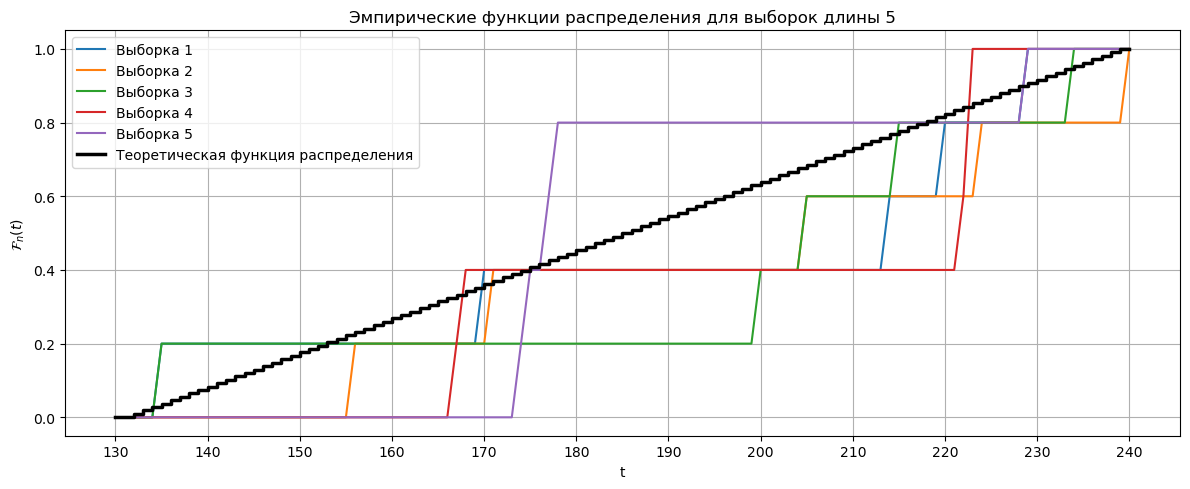

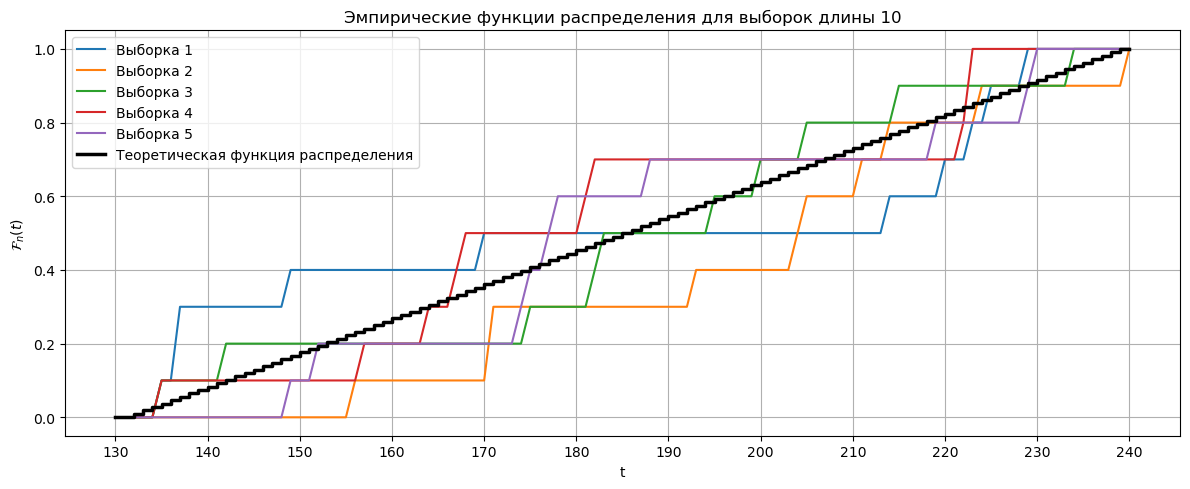

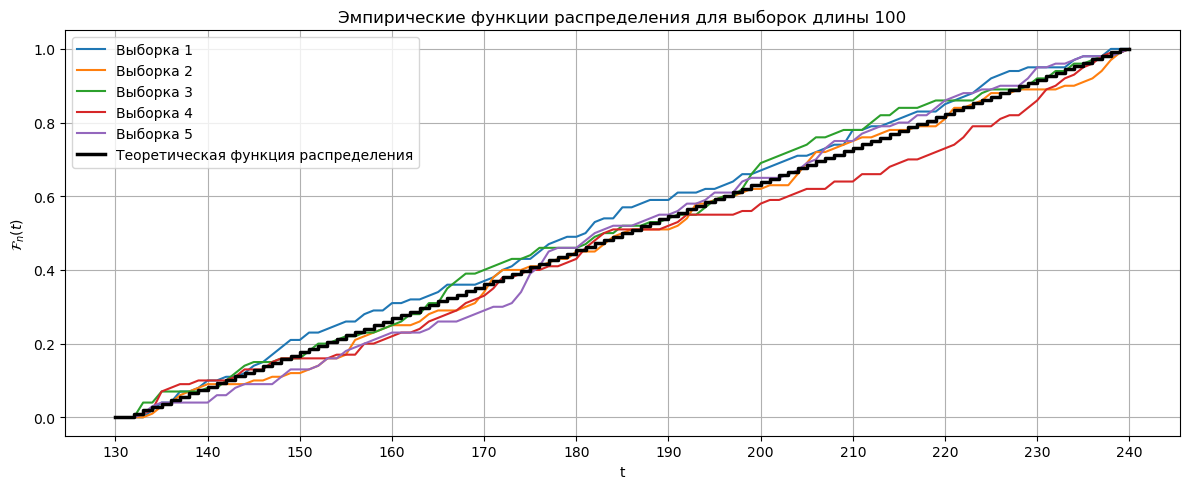

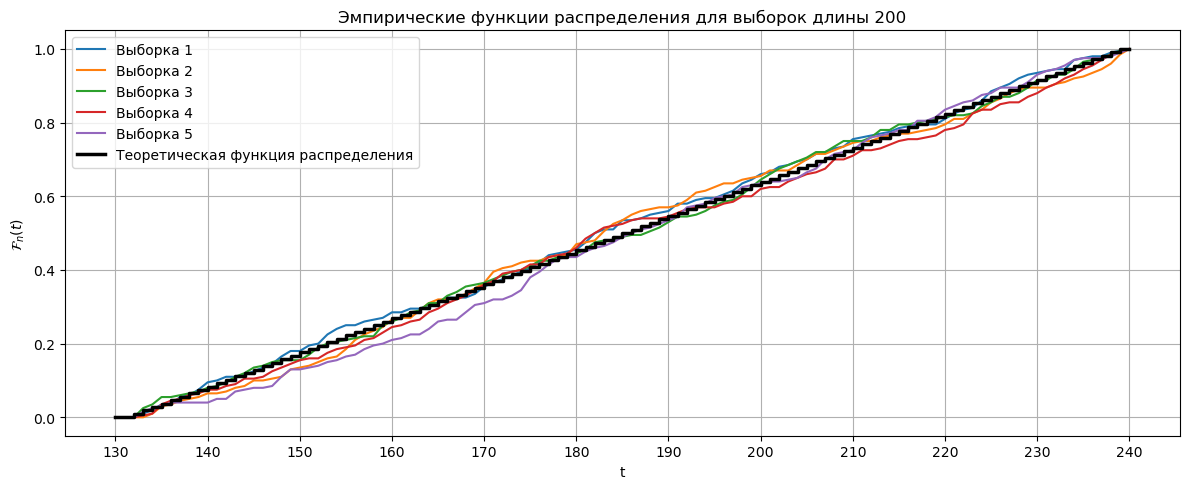

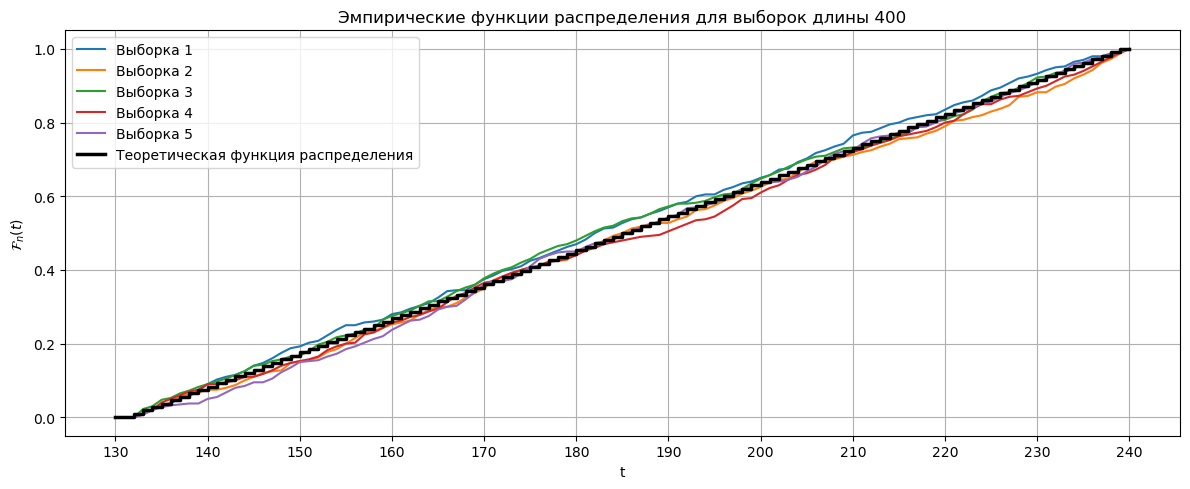

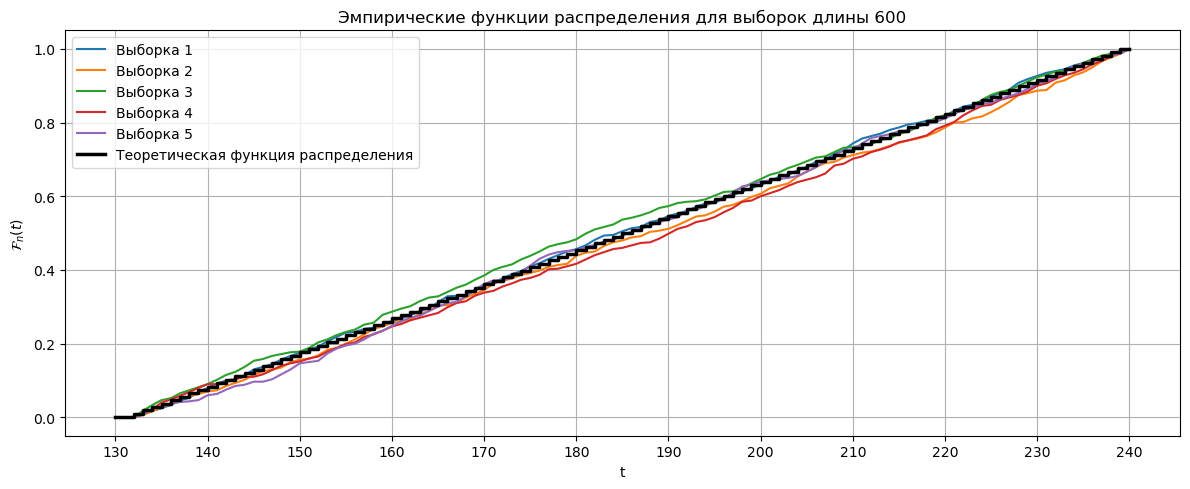

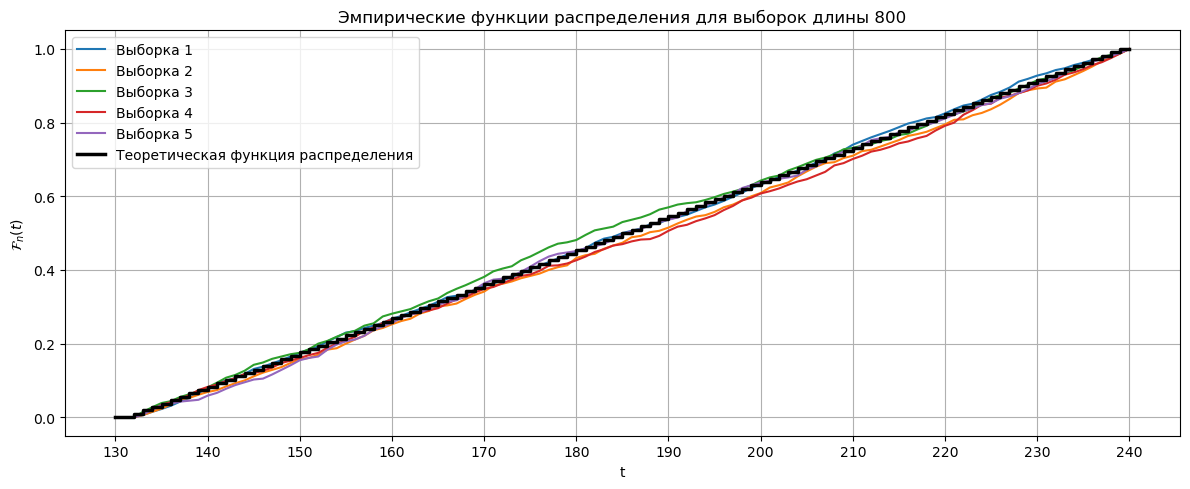

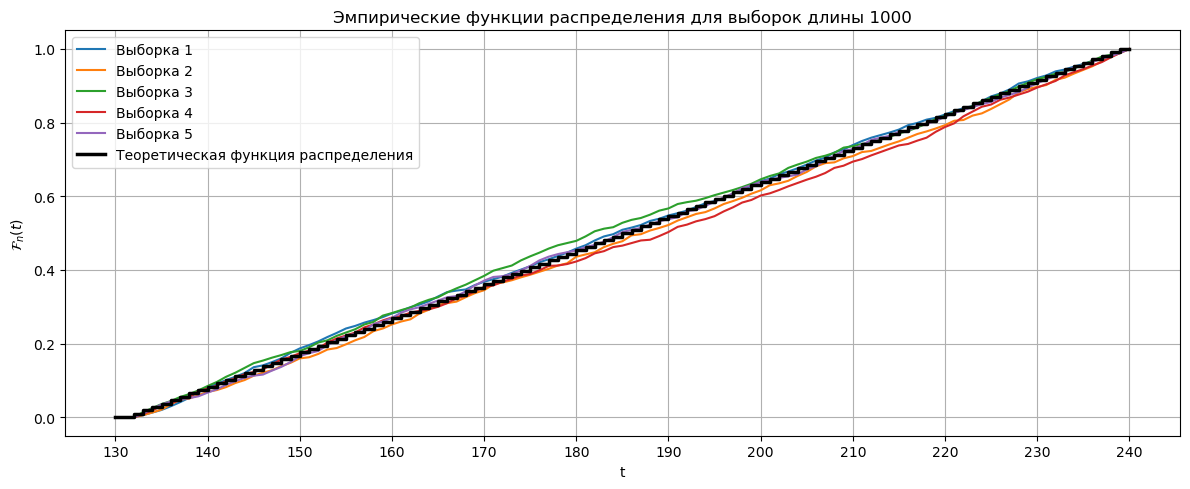

In [32]:
import matplotlib.pyplot as plt

# Эмпирическая функция распределения
def UniFn(t, Uniar):
    return np.sum(np.array(Uniar) < t)/len(Uniar)

# Функция распределения случайной величины
def DistrFunc(t):
    if t < a:
        return 0
    elif t >= a + theta1 - 1:
        return 1
    else:
        return (t - a + 1) / float(theta1)

tmin = 130.0
tmax = 240.0
count = 111
tlist = np.linspace(tmin, tmax, count)
F_theor = [DistrFunc(t) for t in tlist]

#Функция для построения графика выборок одной длины и функции распределения
def ChartEmpiric(Uniar):
    UFlist1 = [UniFn(t, Uniar[0]) for t in tlist]
    UFlist2 = [UniFn(t, Uniar[1]) for t in tlist]
    UFlist3 = [UniFn(t, Uniar[2]) for t in tlist]
    UFlist4 = [UniFn(t, Uniar[3]) for t in tlist]
    UFlist5 = [UniFn(t, Uniar[4]) for t in tlist]
    
    plt.figure(figsize=(12,5))
    plt.plot(tlist, UFlist1, label='Выборка 1')
    plt.plot(tlist, UFlist2, label='Выборка 2')
    plt.plot(tlist, UFlist3, label='Выборка 3')
    plt.plot(tlist, UFlist4, label='Выборка 4')
    plt.plot(tlist, UFlist5, label='Выборка 5')
    plt.step(tlist, F_theor, where='post', color='black', linewidth=2.5, label='Теоретическая функция распределения')
    
    plt.title(f'Эмпирические функции распределения для выборок длины {len(Uniar[0])}')
    plt.xlabel('t')
    plt.ylabel(r'$\mathcal{F}_n(t)$')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.locator_params(axis='x', nbins=20) 
    plt.savefig(f"plot{len(Uniar[0])}.png")
    plt.show()
    
    
ChartEmpiric(Uniar5)    #Эмпирические функции распределения для выборок длины 5

ChartEmpiric(Uniar10)   #Эмпирические функции распределения для выборок длины 10

ChartEmpiric(Uniar100)  #Эмпирические функции распределения для выборок длины 100

ChartEmpiric(Uniar200)  #Эмпирические функции распределения для выборок длины 200

ChartEmpiric(Uniar400)  #Эмпирические функции распределения для выборок длины 400

ChartEmpiric(Uniar600)  #Эмпирические функции распределения для выборок длины 600

ChartEmpiric(Uniar800)  #Эмпирические функции распределения для выборок длины 800

ChartEmpiric(Uniar1000) #Эмпирические функции распределения для выборок длины 1000


# <a id="Normalempirical"> Графики эмпирической функции распределения для нормального I распределения</a>

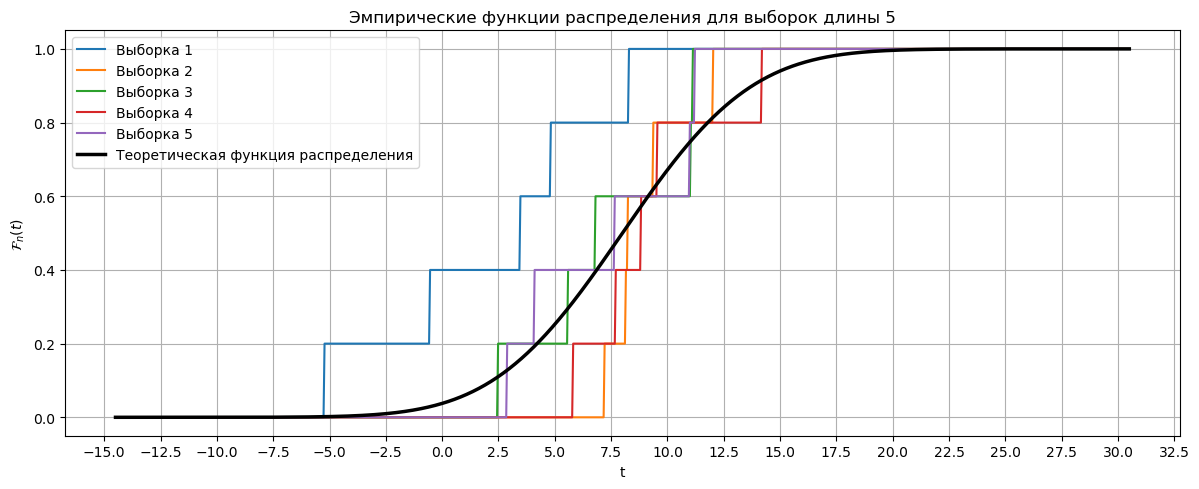

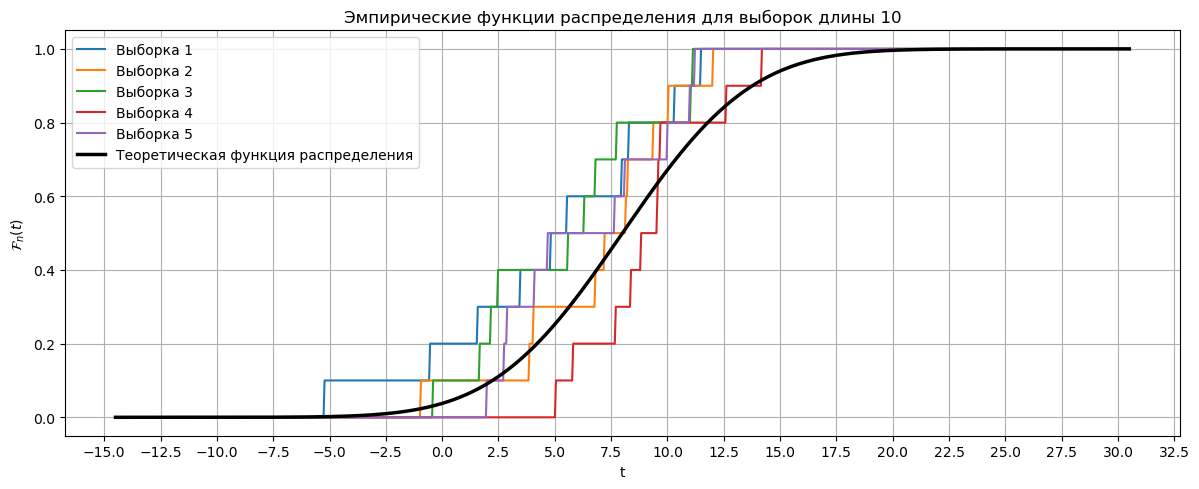

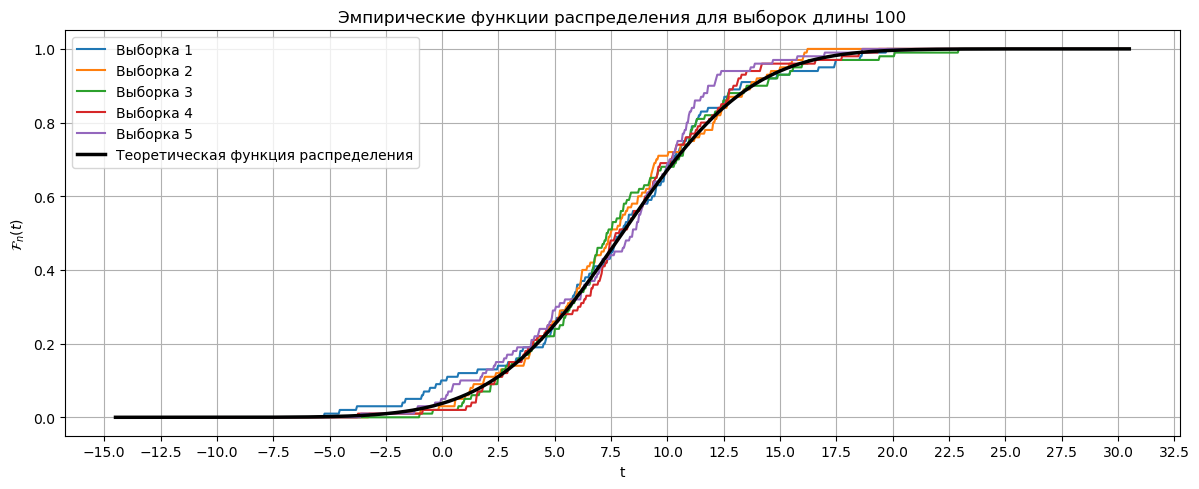

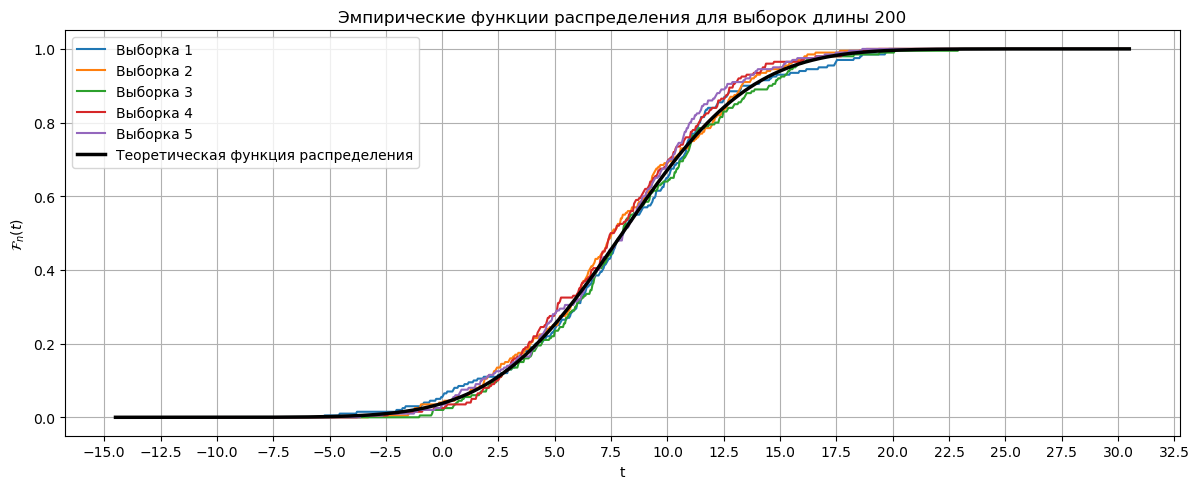

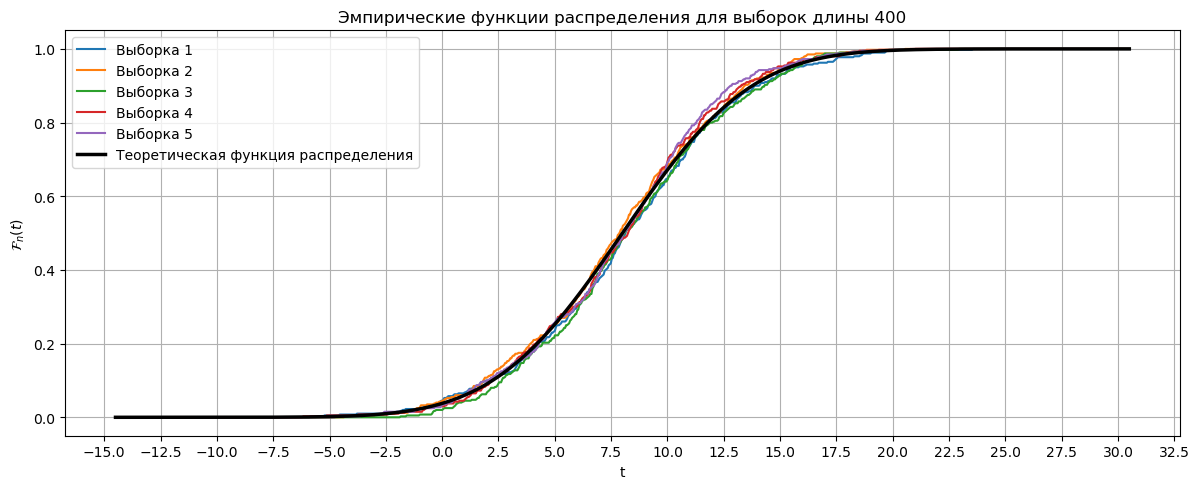

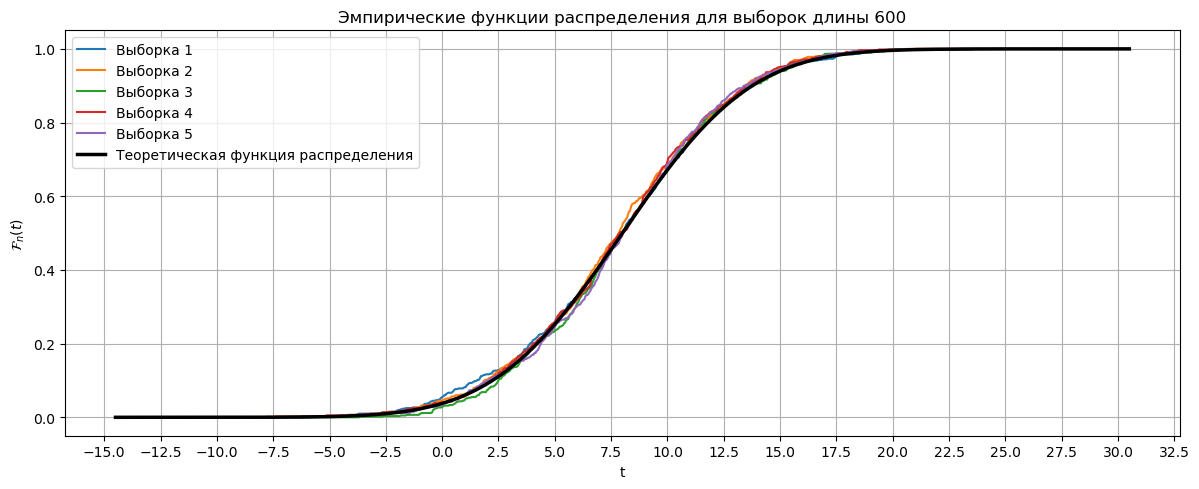

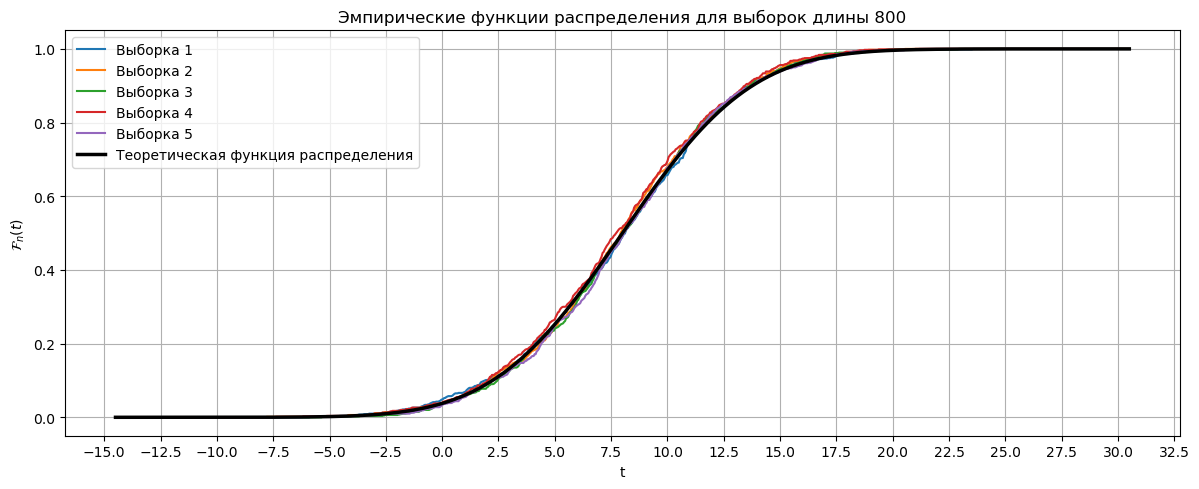

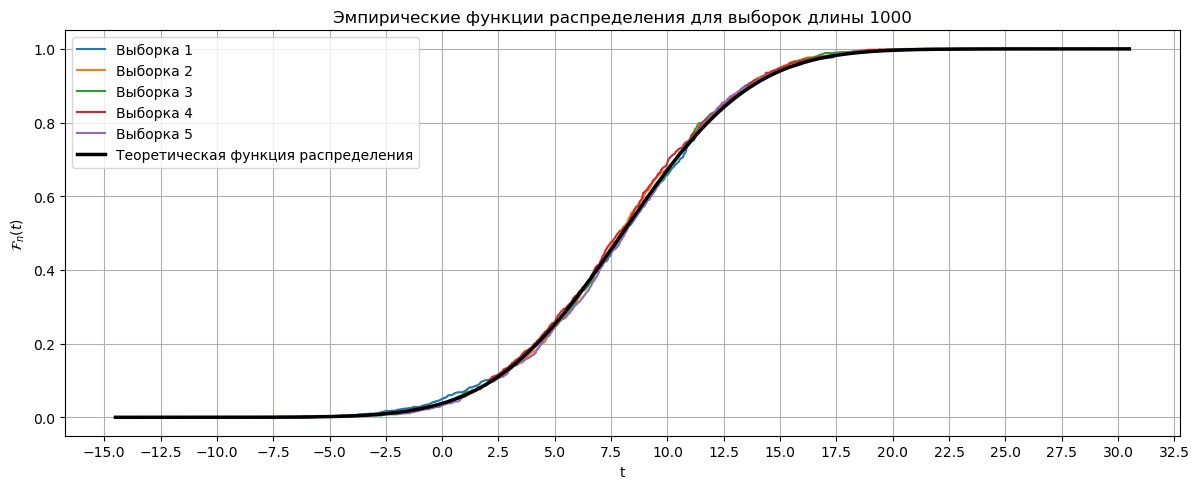

In [34]:
import matplotlib.pyplot as plt
from scipy import integrate

# Эмпирическая функция распределения
def NormalFn(t, Normalar):
    return np.sum(np.array(Normalar) < t)/len(Normalar)
    
# Функция распределения случайной величины
def NormalDistr(t):
    result, _ = integrate.quad(lambda x: 1/(sigma*np.sqrt(2*np.pi)) * np.exp(-(x-theta2)**2/(2*sigma**2)), -np.inf, t)
    return result

nmin = theta2 - 5*sigma
nmax = theta2 + 5*sigma
nlist = np.linspace(nmin, nmax, 1000)
F_normal = [NormalDistr(n) for n in nlist]

#Функция для построения графика выборок одной длины и функции распределения
def GraphtEmpiric(Normalar):
    NFlist1 = [NormalFn(n, Normalar[0]) for n in nlist]
    NFlist2 = [NormalFn(n, Normalar[1]) for n in nlist]
    NFlist3 = [NormalFn(n, Normalar[2]) for n in nlist]
    NFlist4 = [NormalFn(n, Normalar[3]) for n in nlist]
    NFlist5 = [NormalFn(n, Normalar[4]) for n in nlist]
    
    plt.figure(figsize=(12,5))
    plt.plot(nlist, NFlist1, label='Выборка 1')
    plt.plot(nlist, NFlist2, label='Выборка 2')
    plt.plot(nlist, NFlist3, label='Выборка 3')
    plt.plot(nlist, NFlist4, label='Выборка 4')
    plt.plot(nlist, NFlist5, label='Выборка 5')
    plt.plot(nlist, F_normal, color='black', linewidth=2.5, label='Теоретическая функция распределения')
    
    plt.title(f'Эмпирические функции распределения для выборок длины {len(Normalar[0])}')
    plt.xlabel('t')
    plt.ylabel(r'$\mathcal{F}_n(t)$')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.locator_params(axis='x', nbins=20) 
    plt.savefig(f"plotn{len(Normalar[0])}.png")
    plt.show()
GraphtEmpiric(Normalar5)    #Эмпирические функции распределения для выборок длины 5

GraphtEmpiric(Normalar10)   #Эмпирические функции распределения для выборок длины 10

GraphtEmpiric(Normalar100)  #Эмпирические функции распределения для выборок длины 100

GraphtEmpiric(Normalar200)  #Эмпирические функции распределения для выборок длины 200

GraphtEmpiric(Normalar400)  #Эмпирические функции распределения для выборок длины 400

GraphtEmpiric(Normalar600)  #Эмпирические функции распределения для выборок длины 600

GraphtEmpiric(Normalar800)  #Эмпирические функции распределения для выборок длины 800

GraphtEmpiric(Normalar1000) #Эмпирические функции распределения для выборок длины 1000

# <a id="UniDmn"> Вычисление $D_{m,n}$ для дискретного равномерного II распредения</a>

In [36]:
import pandas as pd
def UD(Uniar_1, Uniar_2):
    supp = max([abs(UniFn(t, Uniar_1) - UniFn(t, Uniar_2)) for t in np.linspace(130, 240, 111)])
    return np.sqrt(len(Uniar_1) * len(Uniar_2) / (len(Uniar_1) + len(Uniar_2))) * supp

Uni_samples = {
    5: Uniar5,
    10: Uniar10,
    100: Uniar100,
    200: Uniar200,
    400: Uniar400,
    600: Uniar600,
    800: Uniar800,
    1000: Uniar1000
}
rows = []

for m_len, samples_m in Uni_samples.items():
    for i, sample_m in enumerate(samples_m):
        for n_len, samples_n in Uni_samples.items():
            for j, sample_n in enumerate(samples_n):
                UD_value = UD(sample_m, sample_n)
                rows.append({
                    'm': f'{m_len}_{i+1}',
                    'n': f'{n_len}_{j+1}',
                    'UD': round(UD_value, 3)
                })

df_UD = pd.DataFrame(rows)

In [37]:
df_UD.head(20)

,m,n,UD
0,5_1,5_1,0.000
1,5_1,5_2,0.316
2,5_1,5_3,0.316
3,5_1,5_4,0.632
4,5_1,5_5,0.632
5,5_1,10_1,0.365
6,5_1,10_2,0.548
7,5_1,10_3,0.730
8,5_1,10_4,0.548
9,5_1,10_5,0.548


# <a id="NormalDmn"> Вычисление $D_{m,n}$ для нормального I распредения</a>


In [39]:
import pandas as pd
def ND(Normalar_1, Normalar_2):
    supp = max([abs(NormalFn(t, Normalar_1) - NormalFn(t, Normalar_2)) for t in np.linspace(theta2 - 5*sigma, theta2 + 5*sigma, 1000)])
    return np.sqrt(len(Normalar_1) * len(Normalar_2) / (len(Normalar_1) + len(Normalar_2))) * supp

NUni_samples = {
    5: Normalar5,
    10: Normalar10,
    100: Normalar100,
    200: Normalar200,
    400: Normalar400,
    600: Normalar600,
    800: Normalar800,
    1000: Normalar1000
}
rowsn = []

for m_len, samples_m in NUni_samples.items():
    for i, sample_m in enumerate(samples_m):
        for n_len, samples_n in NUni_samples.items():
            for j, sample_n in enumerate(samples_n):
                ND_value = ND(sample_m, sample_n)
                rowsn.append({
                    'm': f'{m_len}_{i+1}',
                    'n': f'{n_len}_{j+1}',
                    'UD': round(ND_value, 3)
                })

df_ND = pd.DataFrame(rowsn)

In [40]:
df_ND.head(20)

,m,n,UD
0,5_1,5_1,0.000
1,5_1,5_2,1.265
2,5_1,5_3,0.949
3,5_1,5_4,1.265
4,5_1,5_5,0.632
5,5_1,10_1,0.548
6,5_1,10_2,0.913
7,5_1,10_3,0.730
8,5_1,10_4,1.461
9,5_1,10_5,0.730


**3) Построение гистограммы и полигона частот**  
При увеличении объема выборки и уменьшении длин интервалов гистограмма и полигон относительных частот приближаются к графику неизвестной функции $f(x)$, плотности вероятности генеральной совокупности.  
По виду гистограммы или полигона частот можно выдвинуть гипотезу о виде распределения генеральной совокупности.  

a) Дискретное равномерное II  
$\triangleleft$ полигон частот и сравнение с функцией вероятности   
[Код для построения полигона частот](#UniPol)  
Посмотрим на гистограмму и полигон частот для выборки №1 объемов 5, 10, 100, 200, 400, 600, 800, 1000. На каждом графике также представлена теоретическая функция вероятности:  
![Полигон](ufreq5_1.png)
![Полигон](ufreq10_1.png)
![Полигон](ufreq100_1.png)
![Полигон](ufreq200_1.png)
![Полигон](ufreq400_1.png)
![Полигон](ufreq600_1.png)
![Полигон](ufreq800_1.png)
![Полигон](ufreq1000_1.png)

б) Нормальное I  
$\triangleleft$ полигон частот и сравнение с плотностью распределения   
[Код для построения полигона частот](#NormalPol)  
Посмотрим на гистограмму и полигон частот для выборки №1 объемов 5, 10, 100, 200, 400, 600, 800, 1000. На каждом графике также представлена функция плотности вероятности:  
![Полигон](nfreq5_1.png)
![Полигон](nfreq10_1.png)
![Полигон](nfreq100_1.png)
![Полигон](nfreq200_1.png)
![Полигон](nfreq400_1.png)
![Полигон](nfreq600_1.png)
![Полигон](nfreq800_1.png)
![Полигон](nfreq1000_1.png)  



# <a id="UniPol"> Функция вероятности и полигон, гистограмма частот для дискретного равномерного II распредения</a>

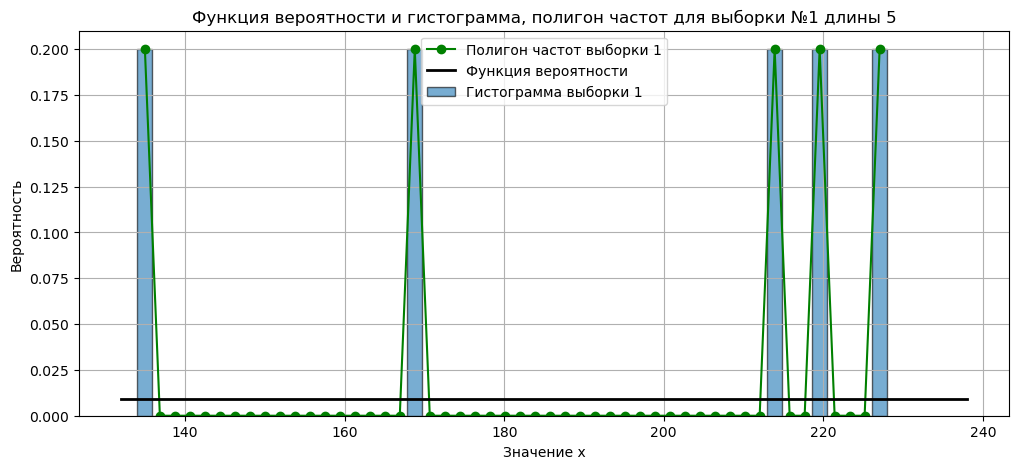

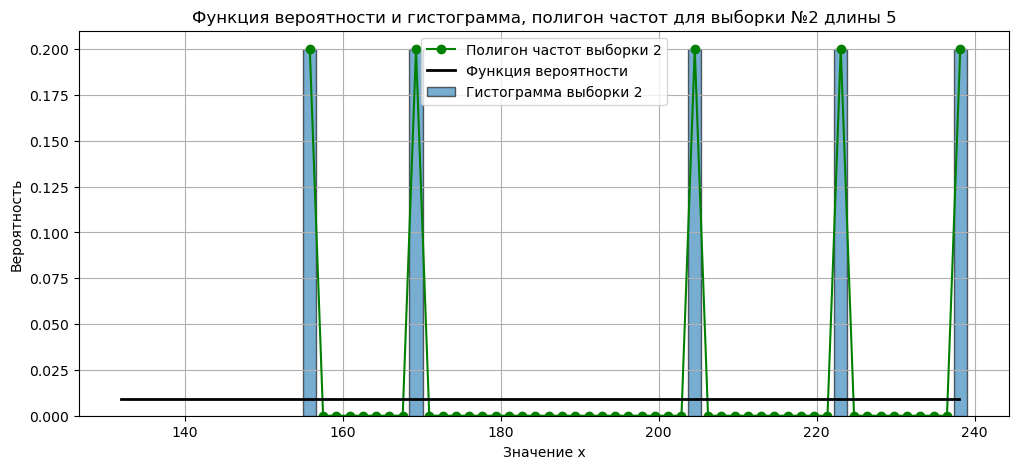

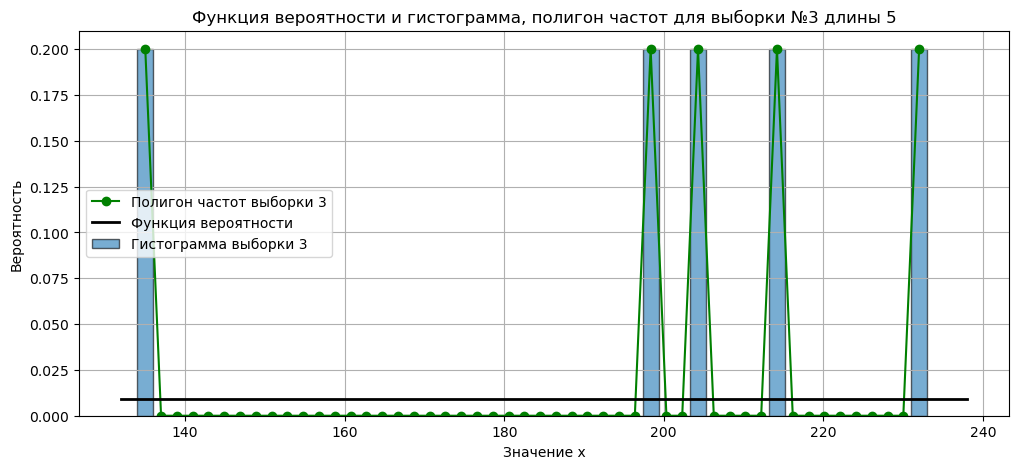

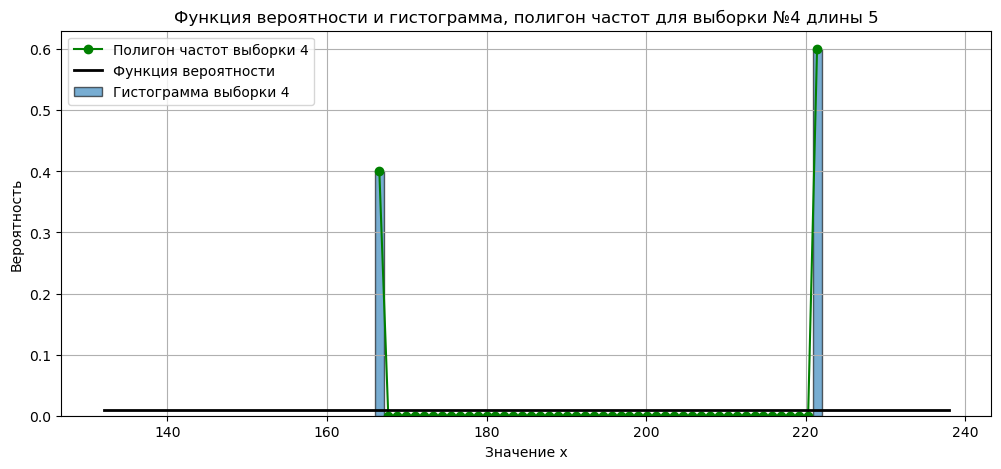

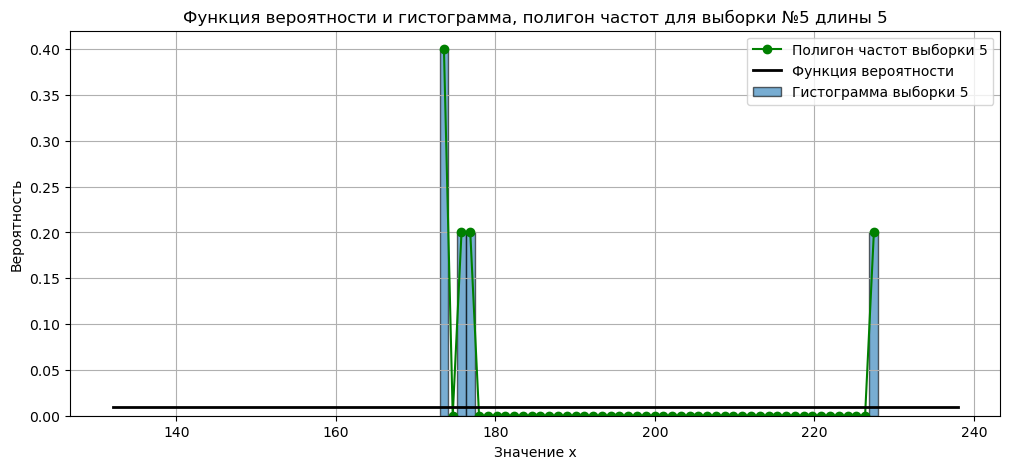

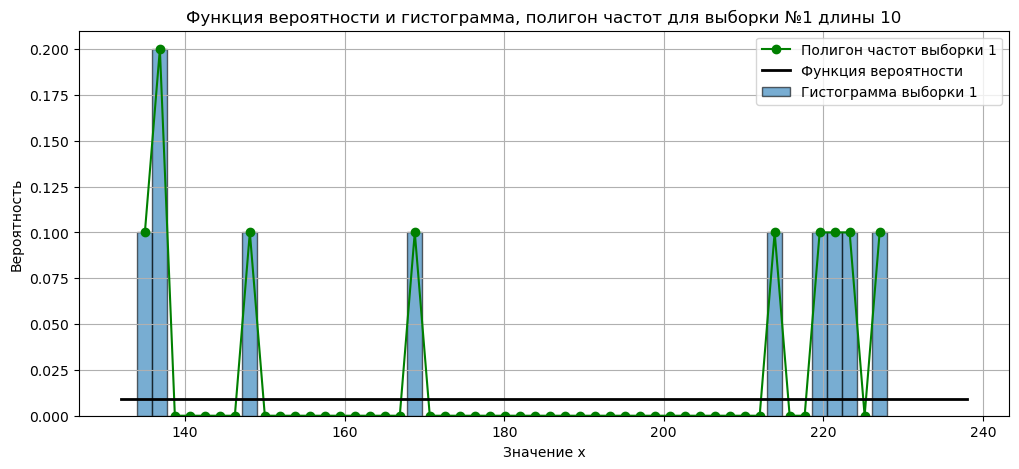

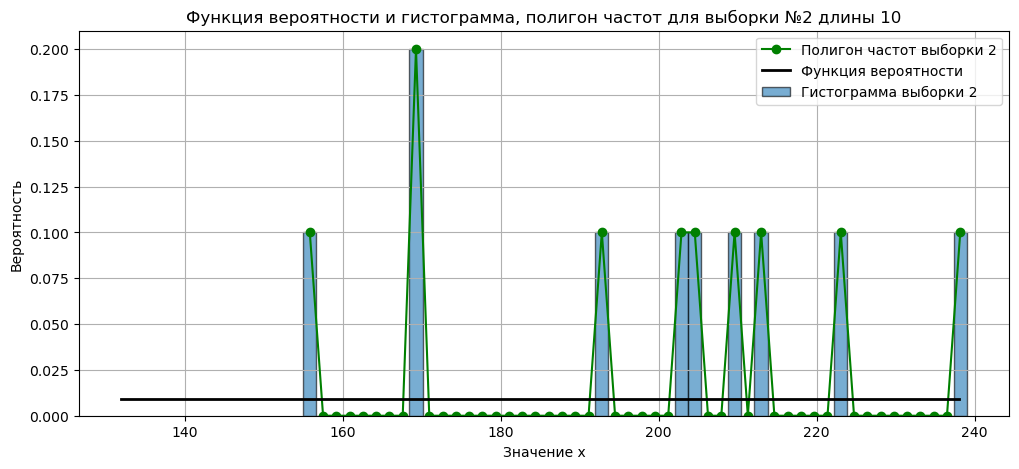

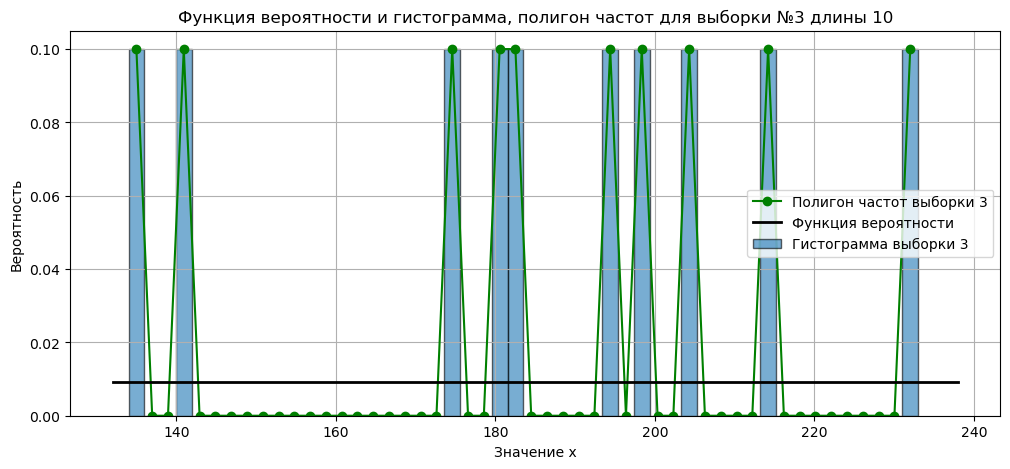

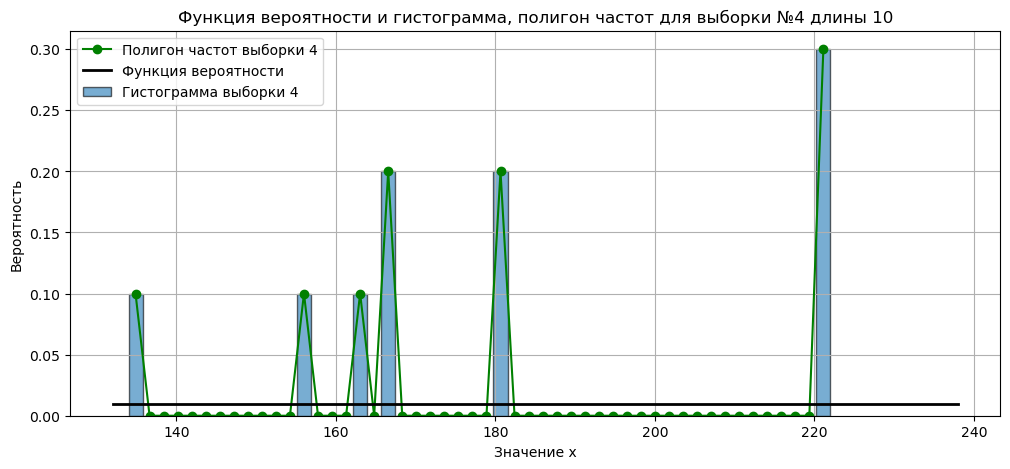

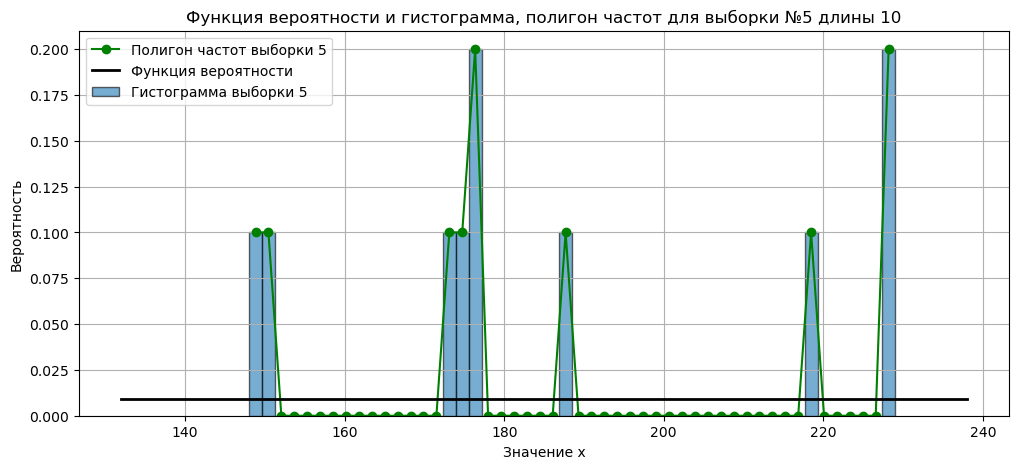

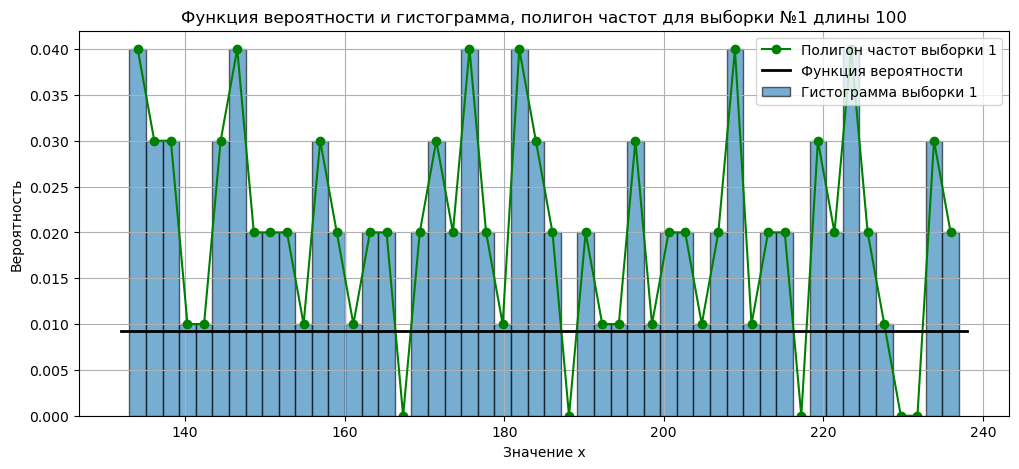

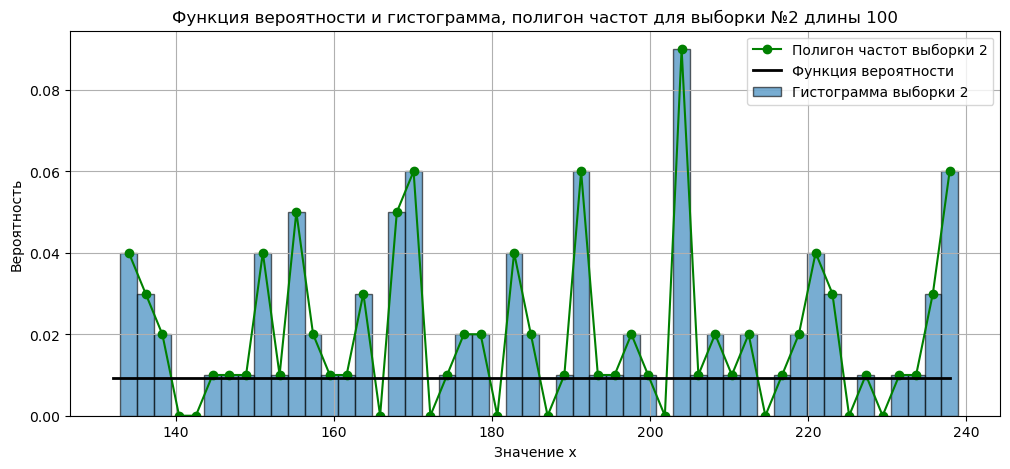

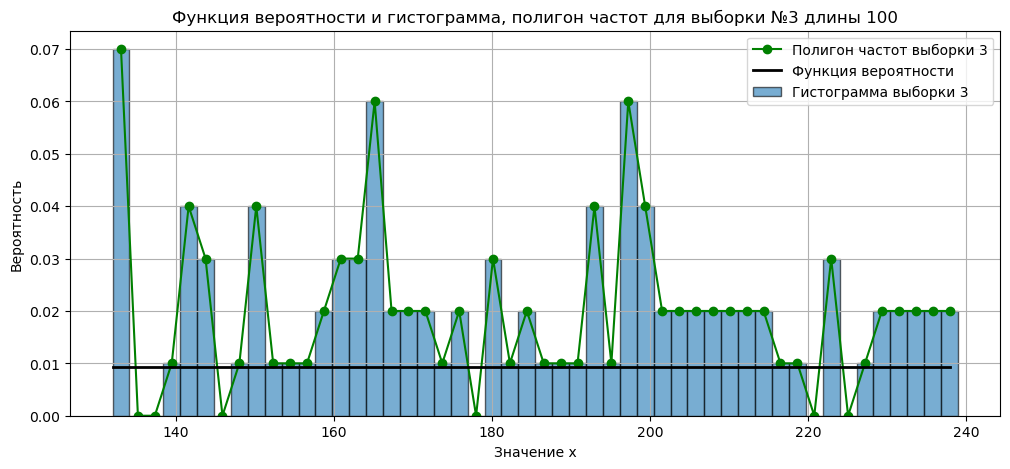

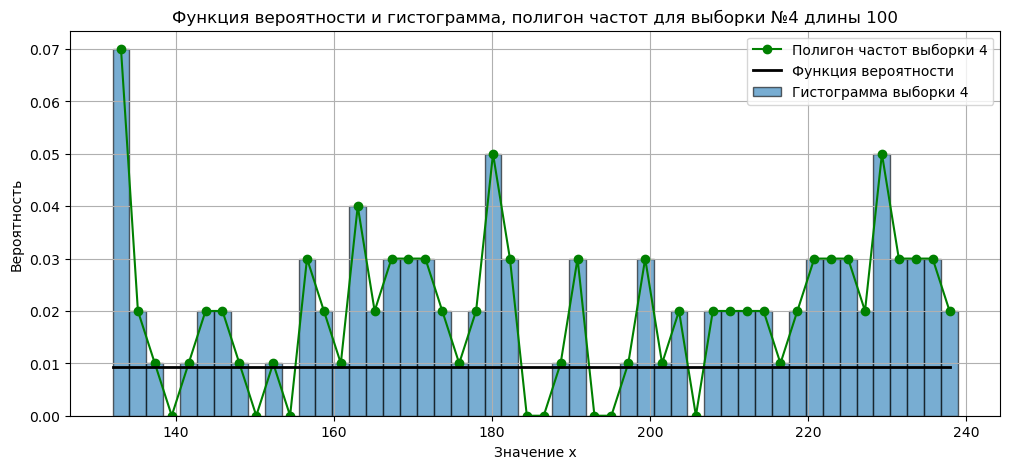

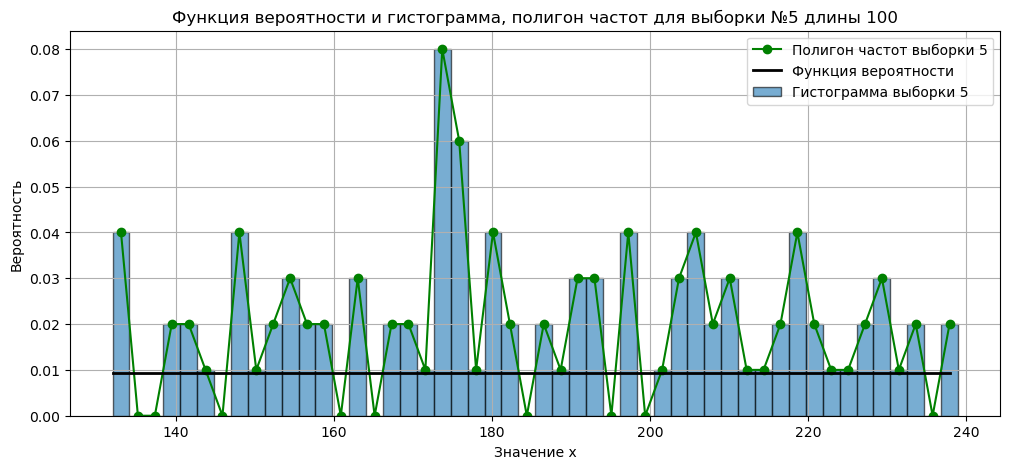

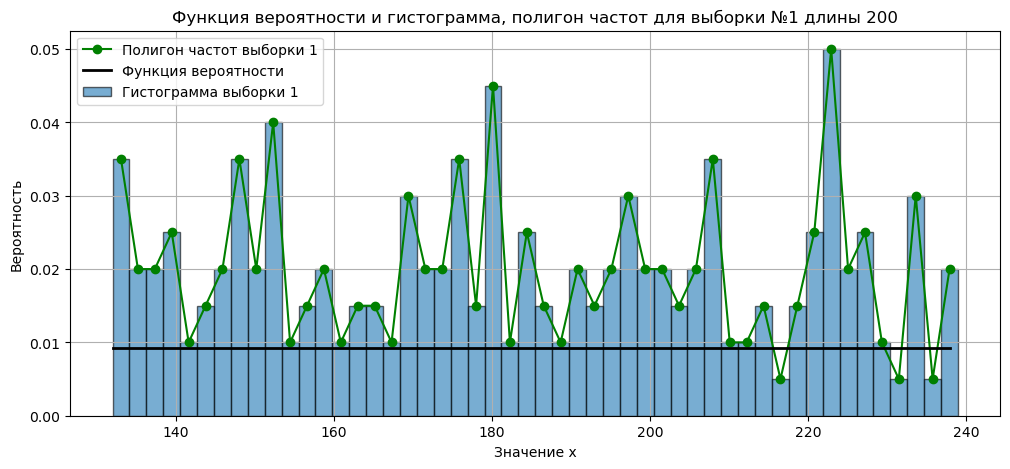

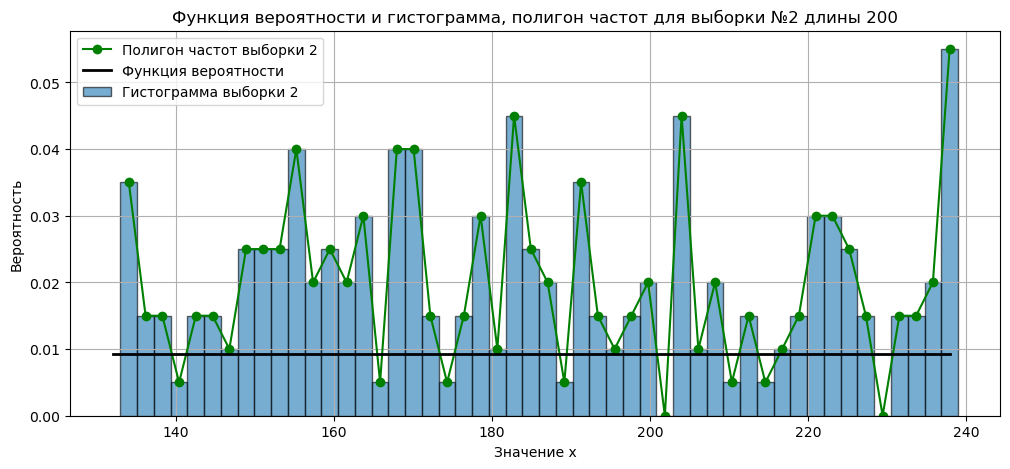

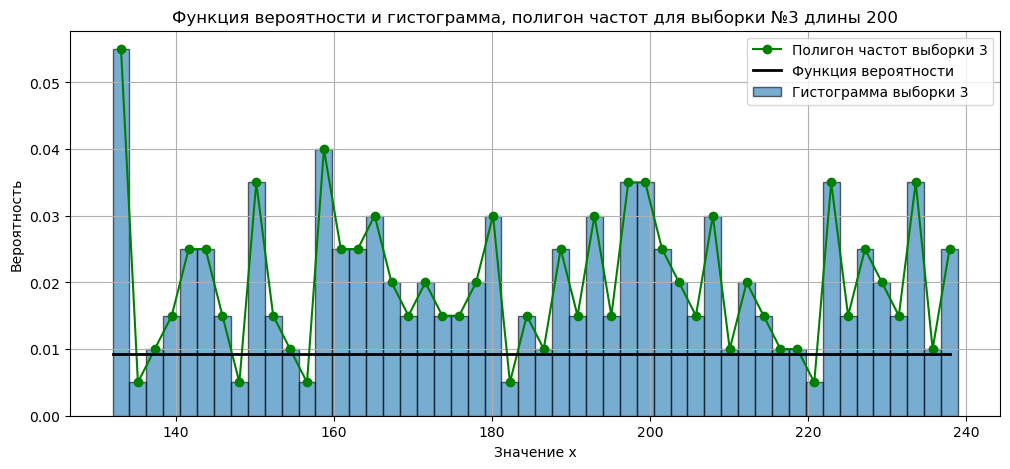

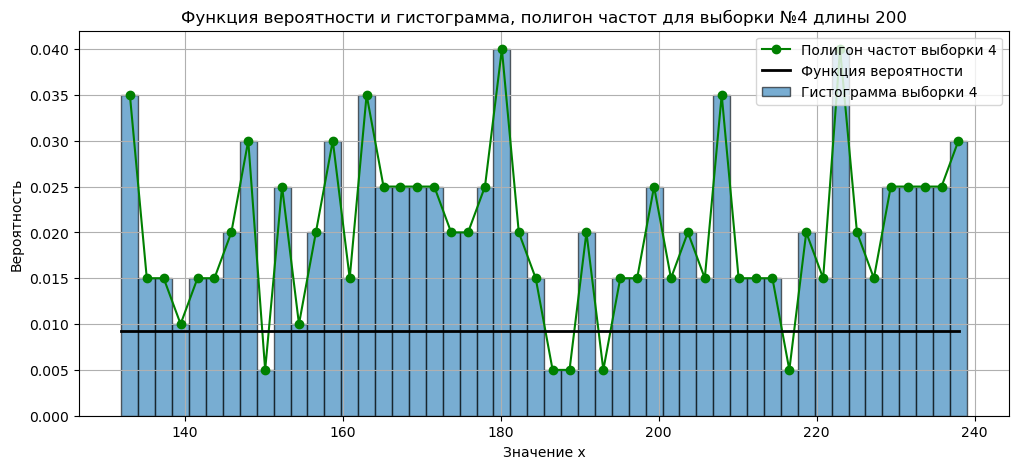

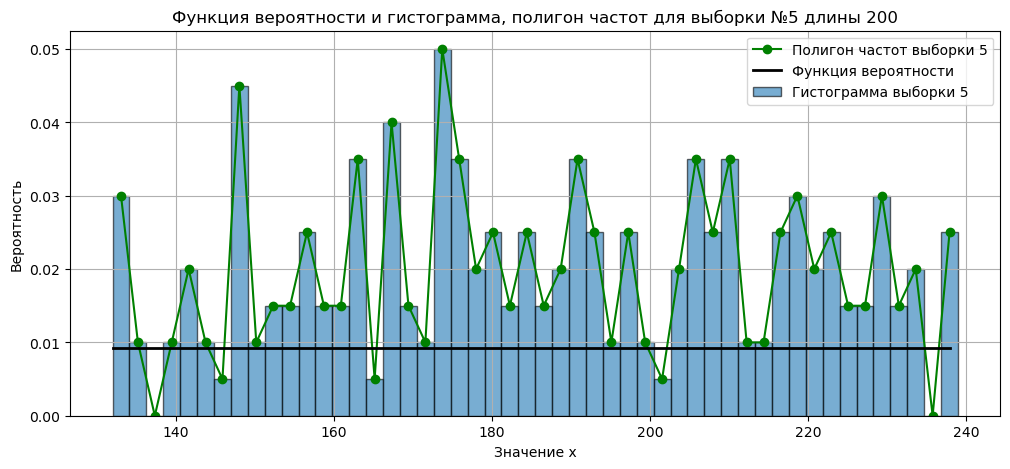

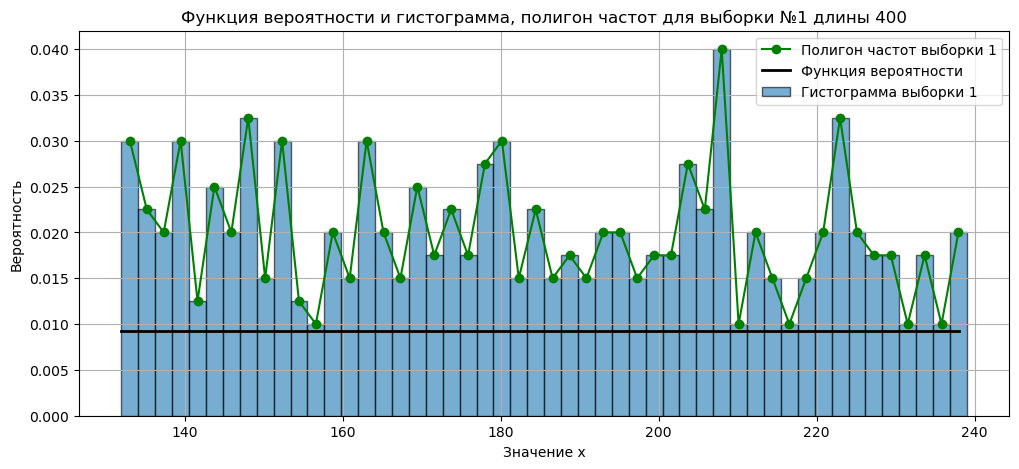

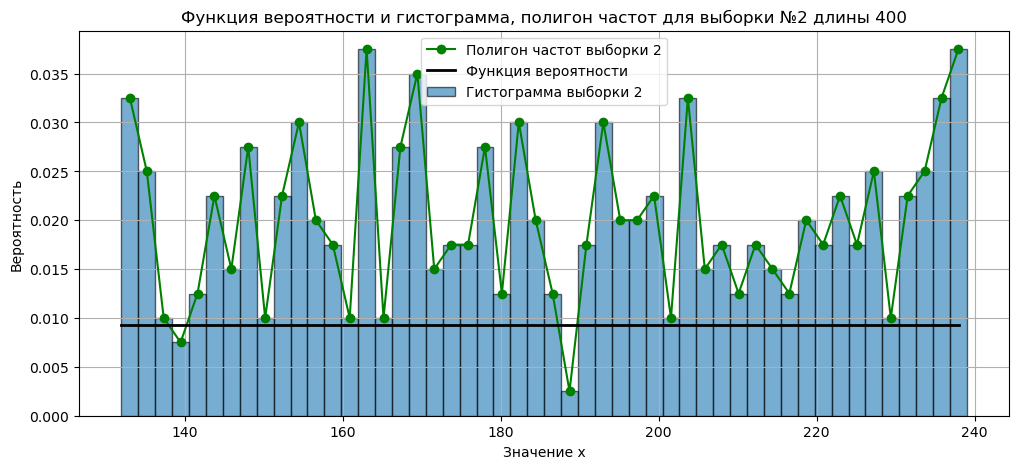

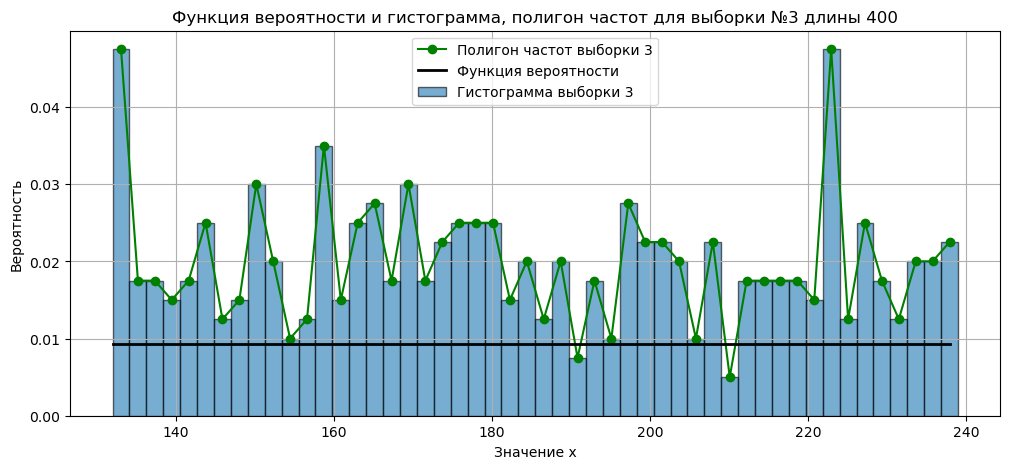

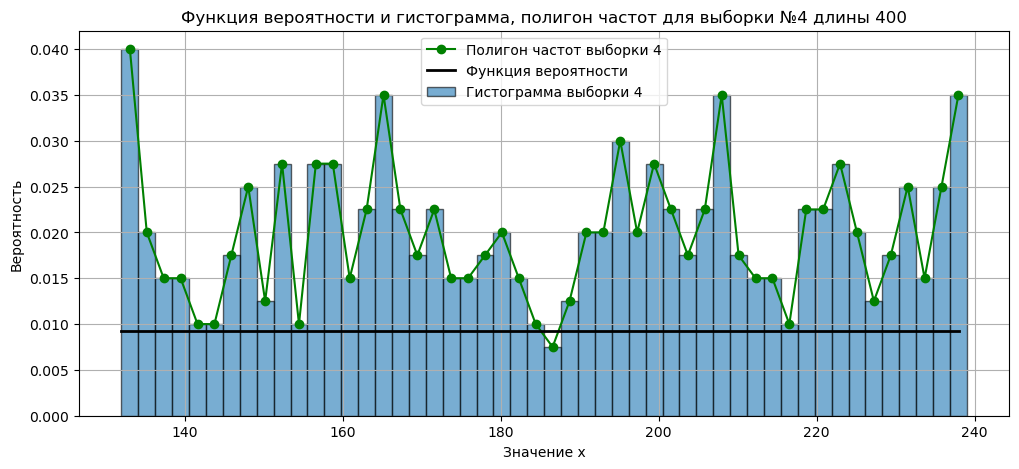

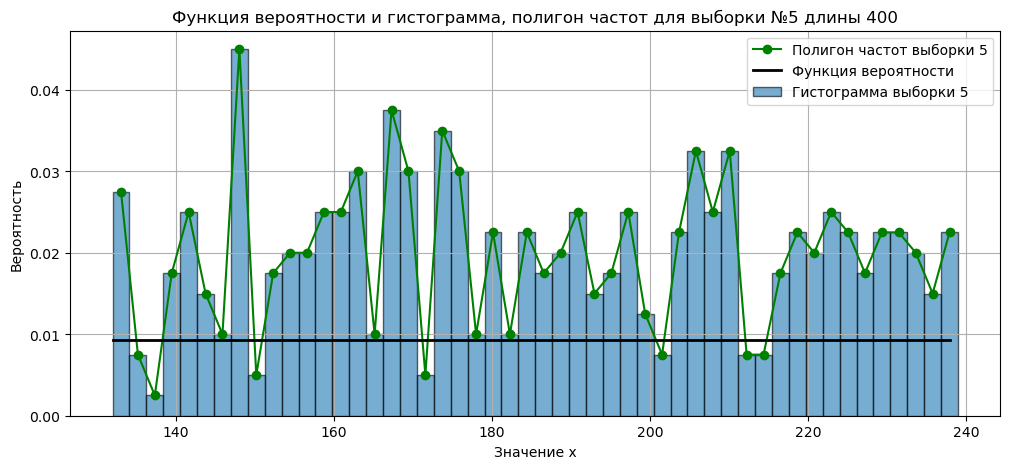

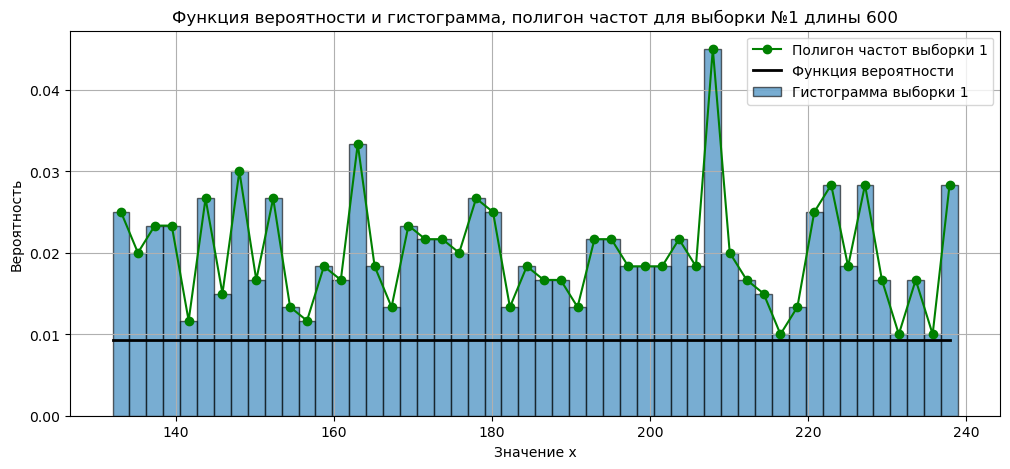

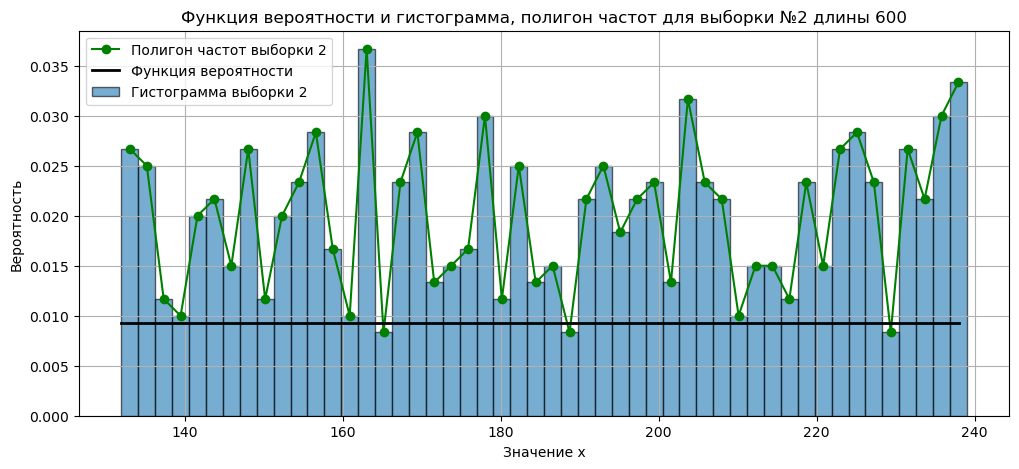

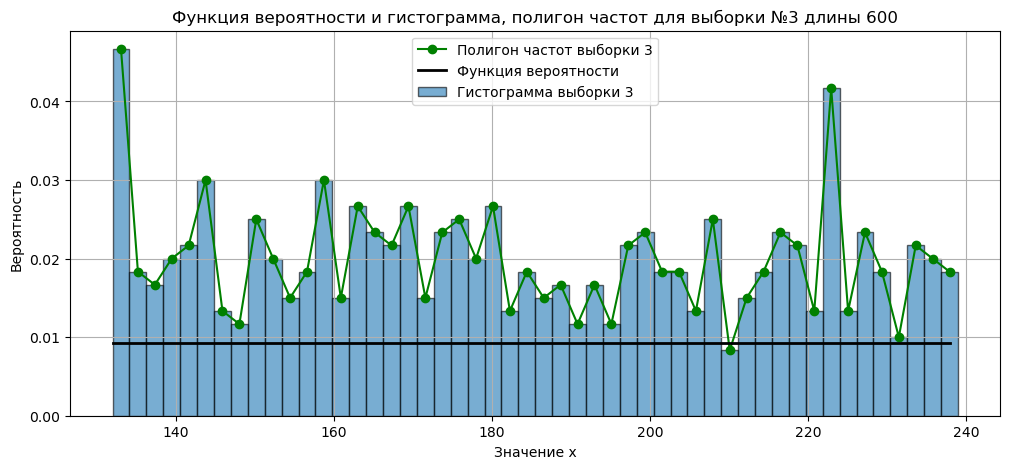

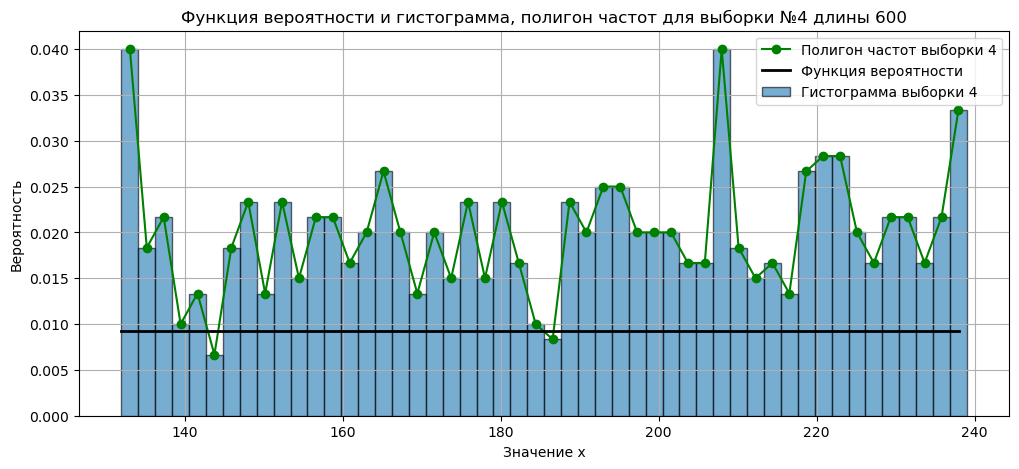

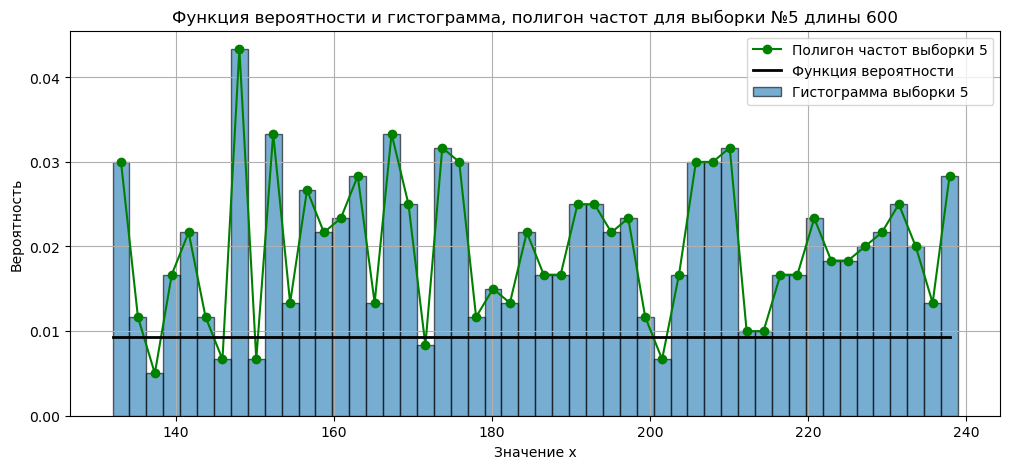

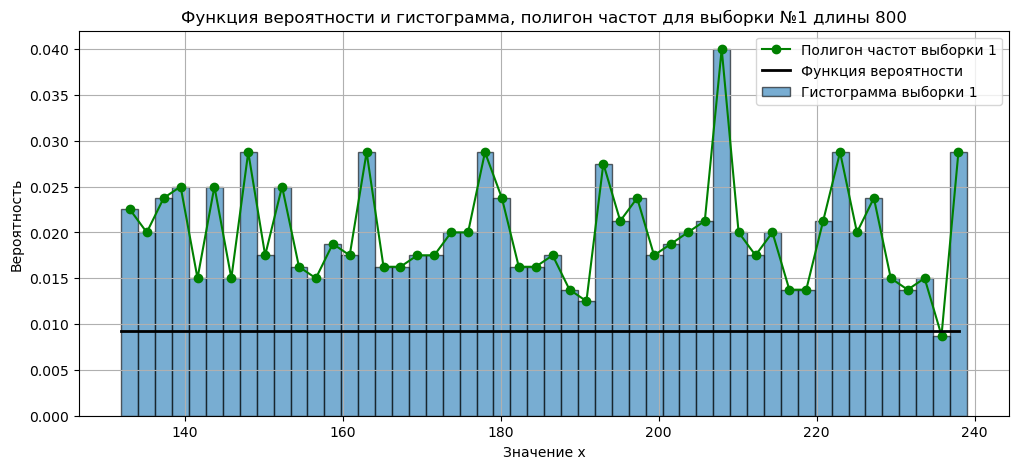

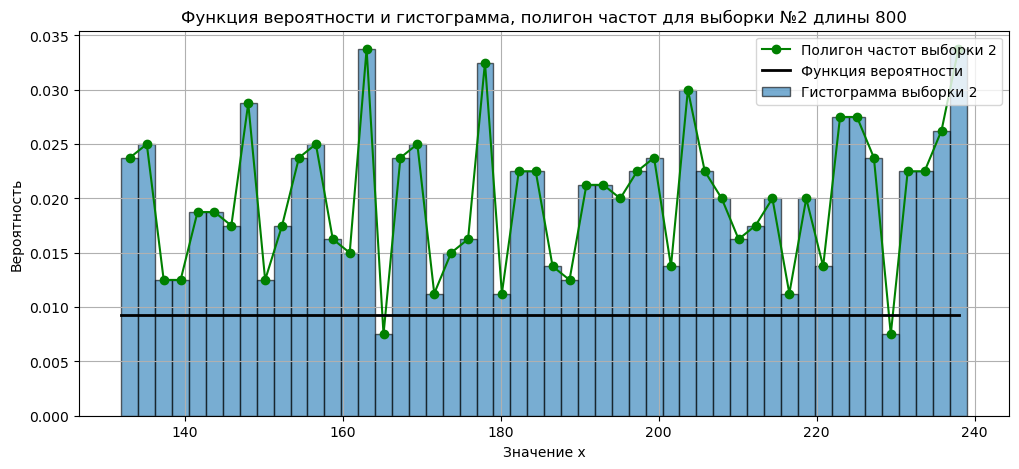

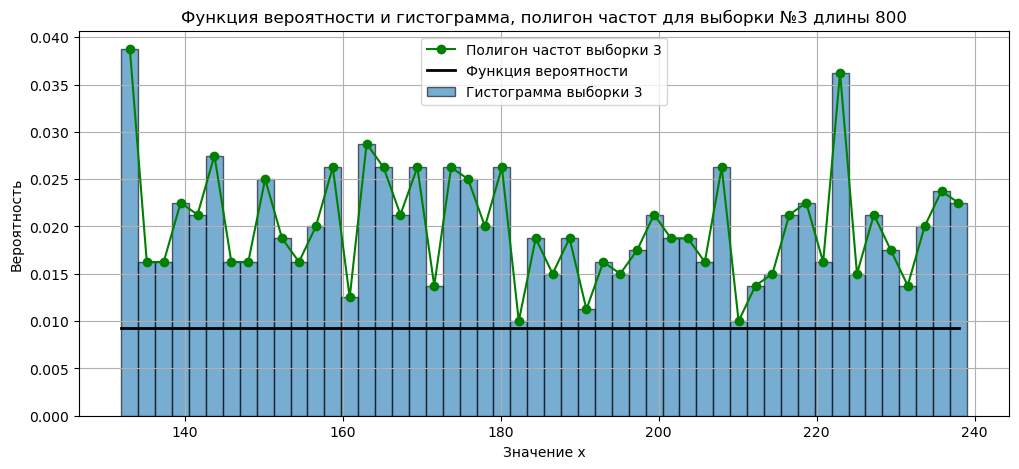

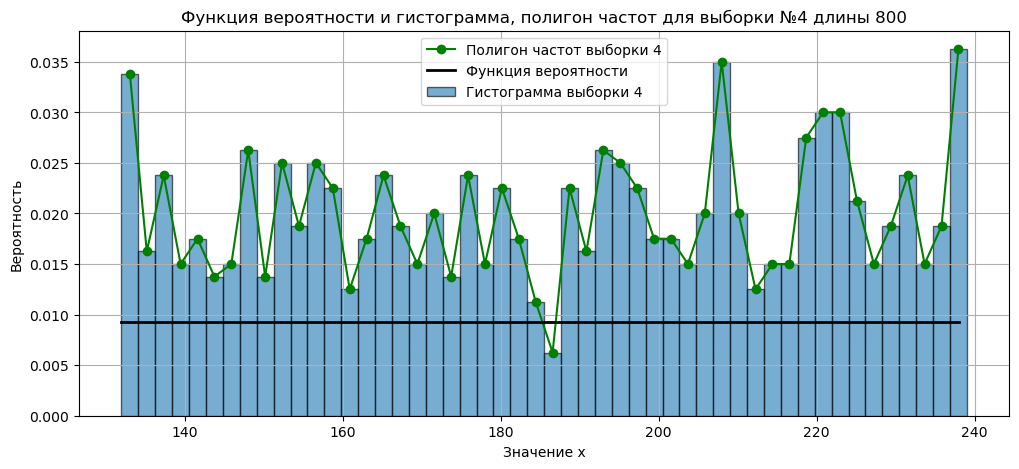

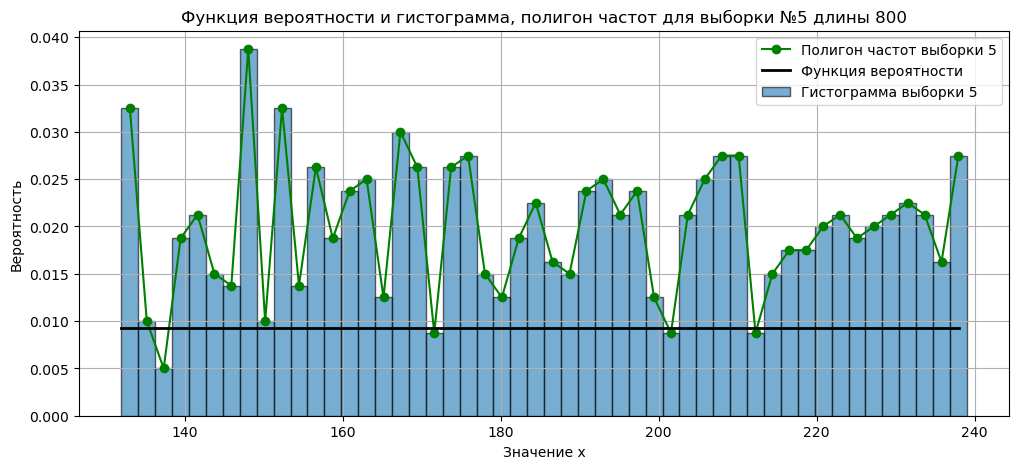

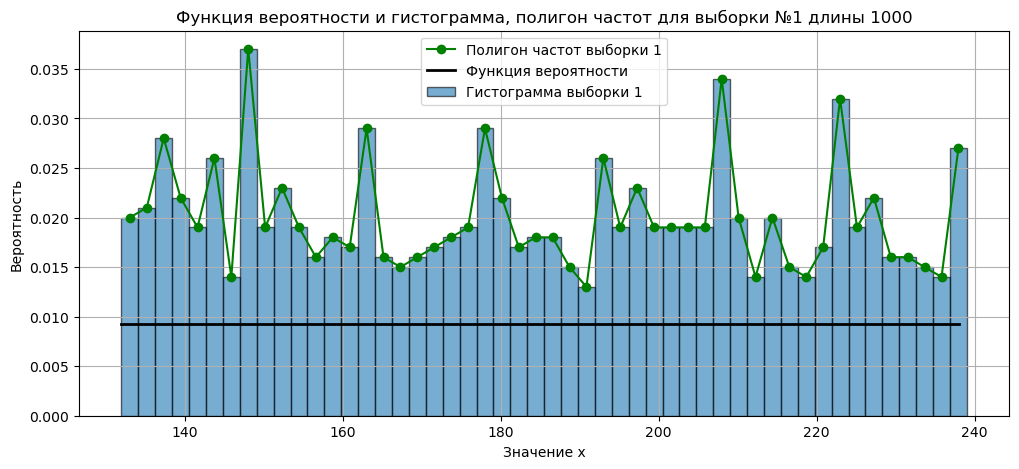

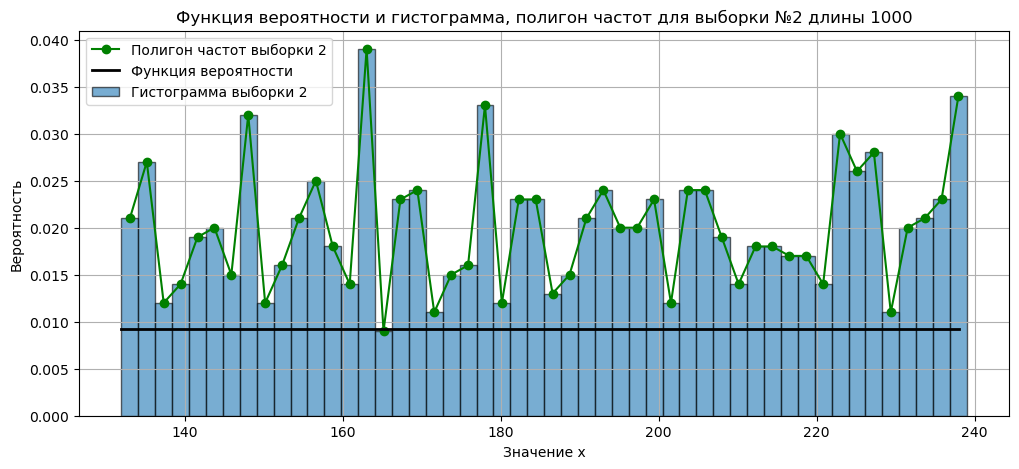

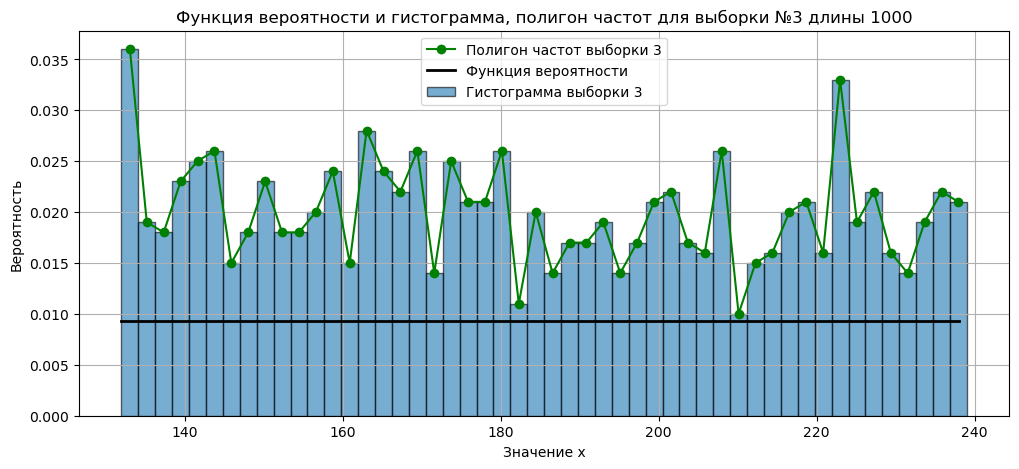

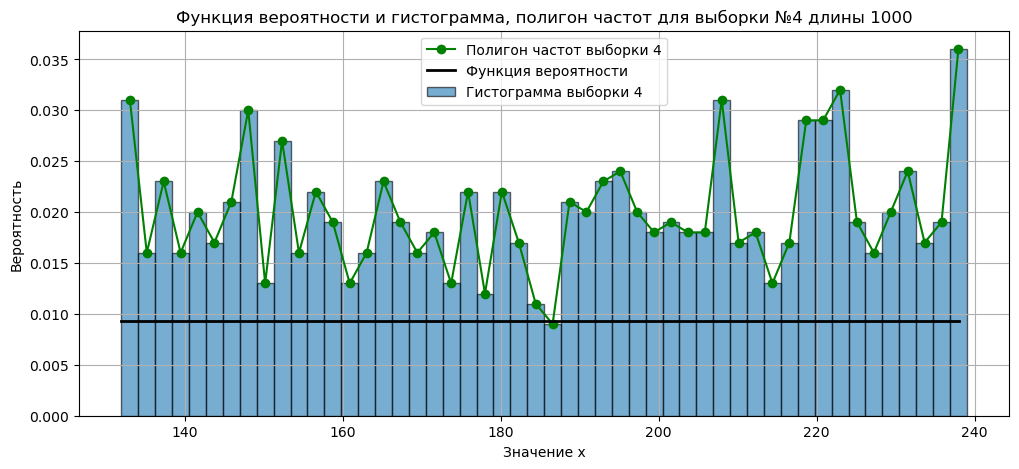

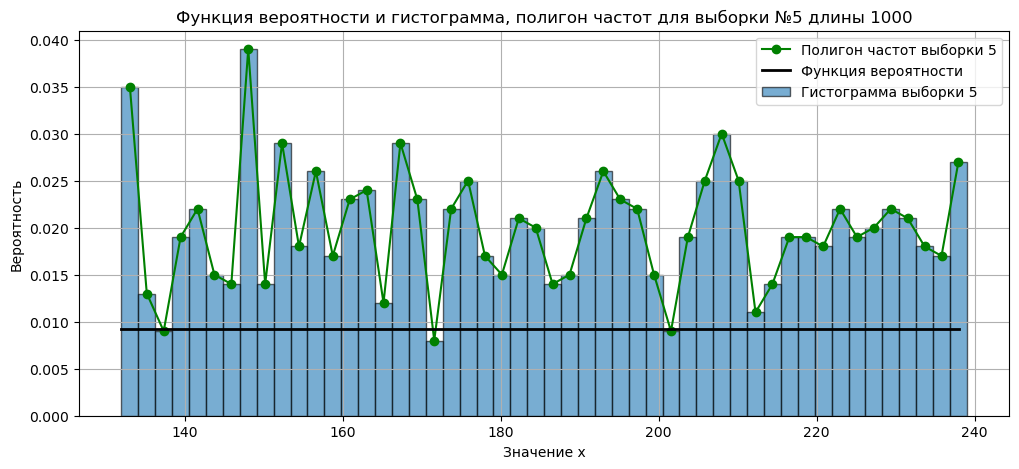

In [43]:
#Функция вероятности
def disc_P(x, a=132, theta=108):
    if a <= x <= a + theta - 1:
        return 1 / theta
    return 0
    
def UniFrequency(Uniar, bins=20, theor_f=None, a=None, theta=None):
    for i, sample in enumerate(Uniar):
        fig, ax = plt.subplots(figsize=(12,5))
        # Считаем частоты
        counts, bin_edges = np.histogram(sample, bins=bins)
        # Нормализуем частоты
        normalized_counts = counts / sum(counts)
        # Гистограмма с нормализованными частотами
        ax.bar(bin_edges[:-1], normalized_counts, width=np.diff(bin_edges), align="edge",
               alpha=0.6, edgecolor='black', label=f'Гистограмма выборки {i+1}')
        # Полигон частот
        bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
        ax.plot(bin_centers, normalized_counts, '-o', color='green', label=f'Полигон частот выборки {i+1}')
        # Теоретическая функция вероятности
        if theor_f is not None and a is not None and theta is not None:
            t_values = np.arange(a, a + theta - 1)
            theoretical_values = [theor_f(t) for t in t_values]
            ax.step(t_values, theoretical_values, color='black', linestyle='-', linewidth=2, label='Функция вероятности')

        ax.set_title(f'Функция вероятности и гистограмма, полигон частот для выборки №{i+1} длины {len(sample)}')
        ax.set_xlabel('Значение x')
        ax.set_ylabel('Вероятность')
        ax.grid(True)
        ax.legend()
        plt.savefig(f"ufreq{len(sample)}_{i+1}.png")
        plt.show()
        plt.close()
UniFrequency(Uniar5, 50, disc_P, 132, 108) 
UniFrequency(Uniar10, 50, disc_P, 132, 108)
UniFrequency(Uniar100, 50, disc_P, 132, 108)
UniFrequency(Uniar200, 50, disc_P, 132, 108) 
UniFrequency(Uniar400, 50, disc_P, 132, 108) 
UniFrequency(Uniar600, 50, disc_P, 132, 108)
UniFrequency(Uniar800, 50, disc_P, 132, 108)
UniFrequency(Uniar1000, 50, disc_P, 132, 108) 

# <a id="NormalPol"> Плотность распределения и полигон, гистограмма частот для нормального I распредения</a>

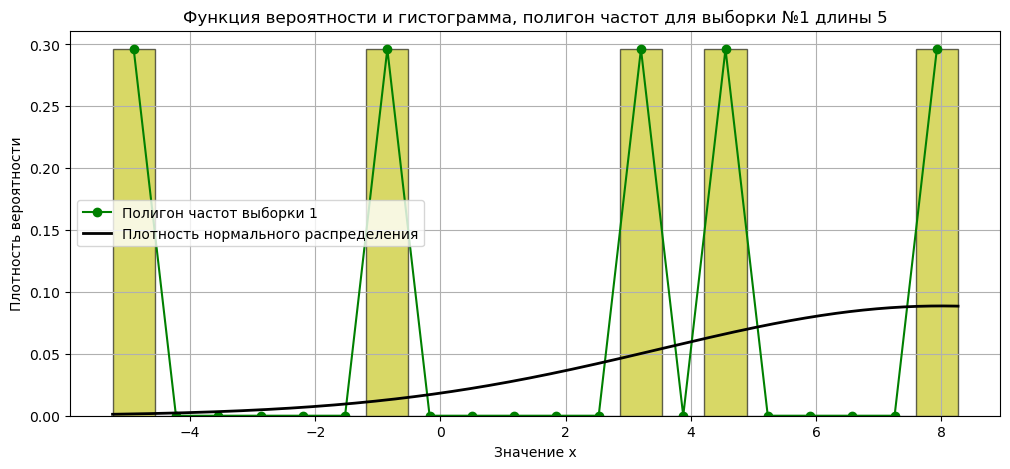

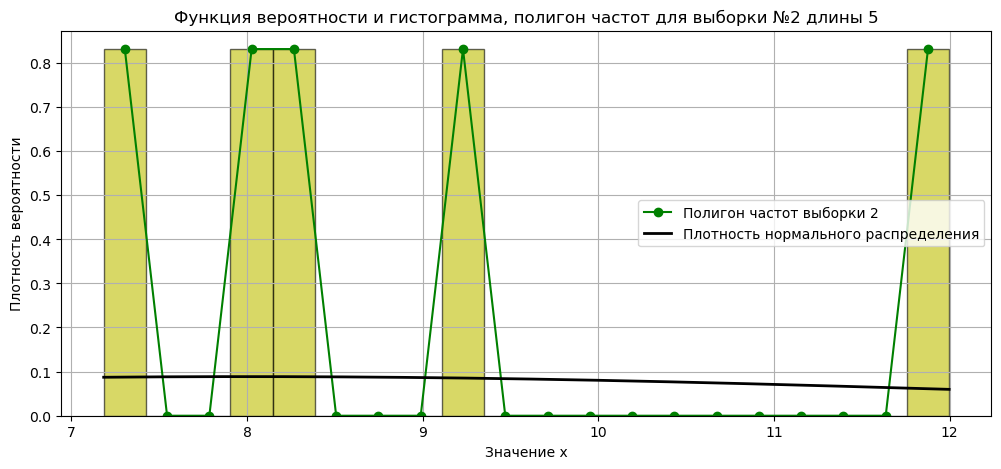

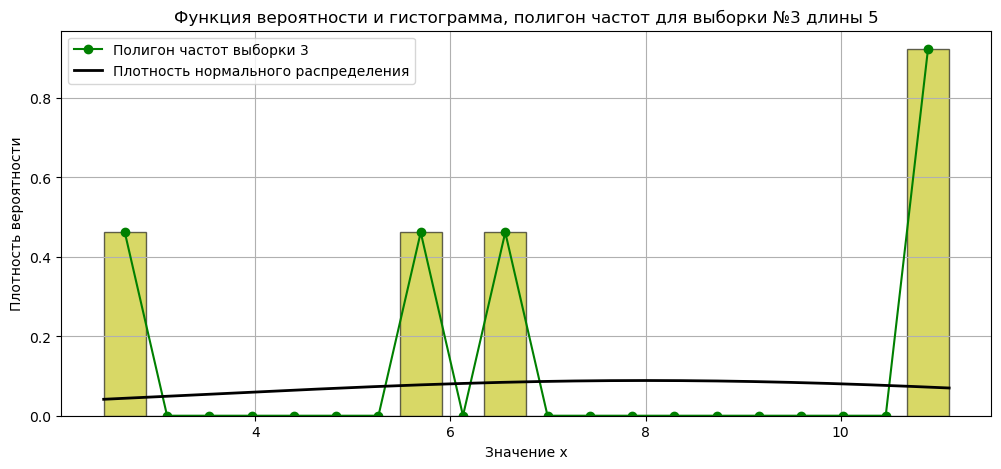

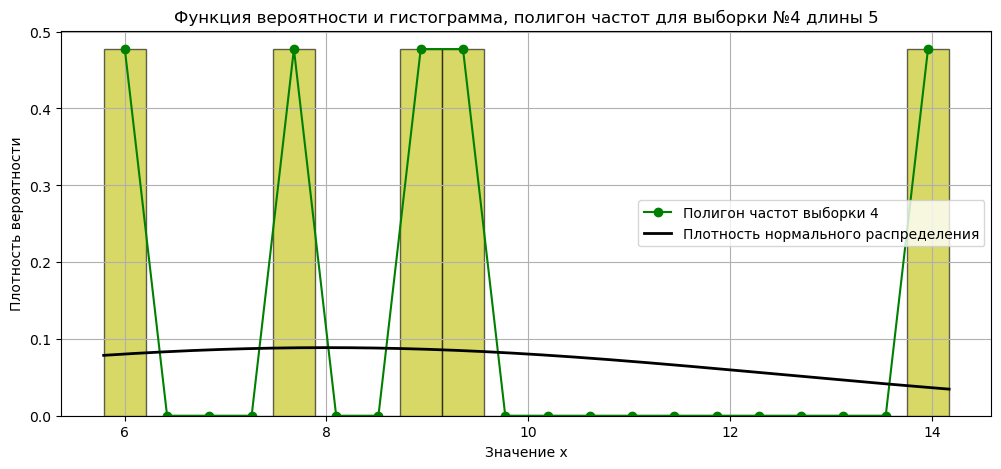

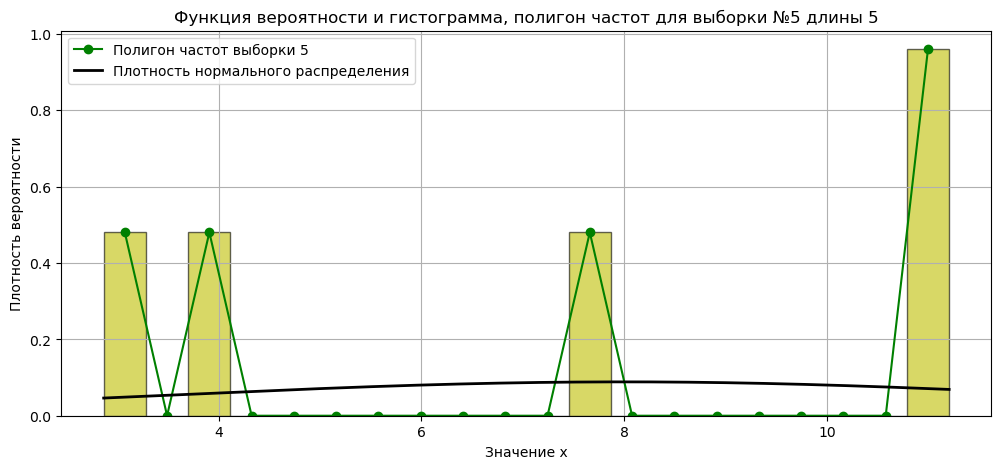

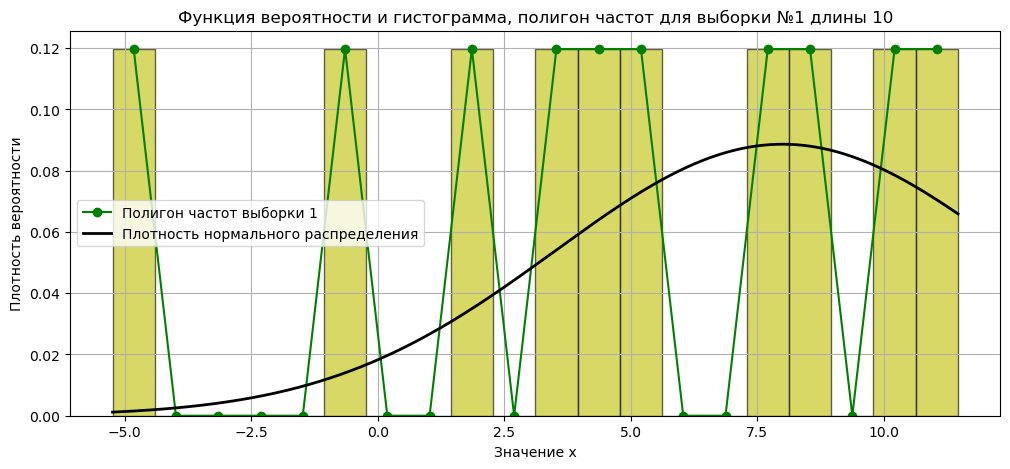

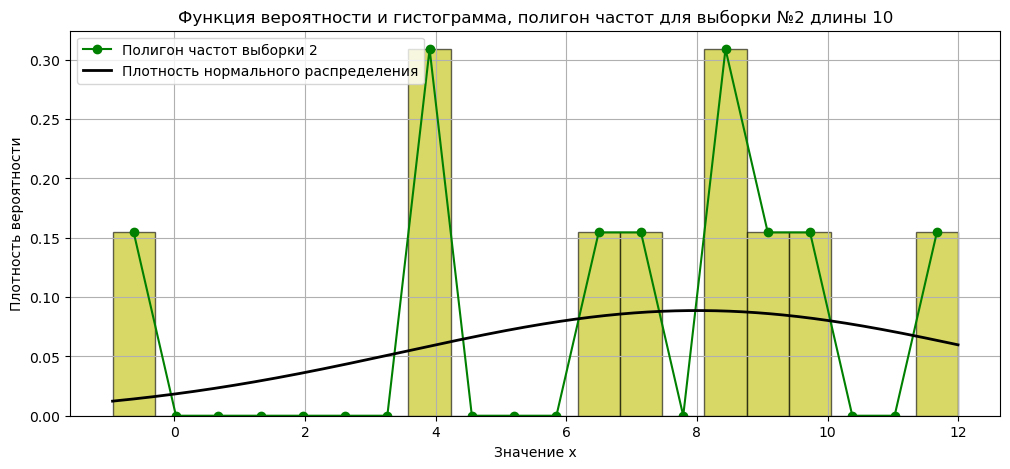

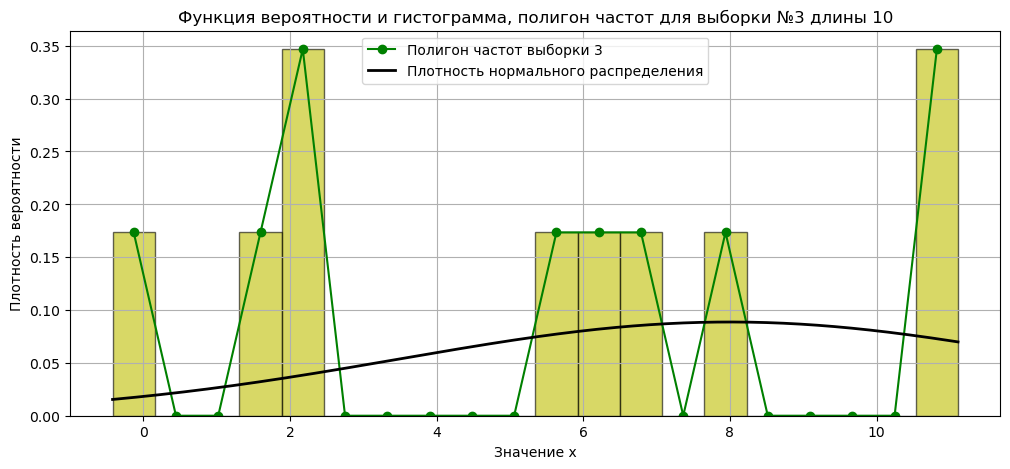

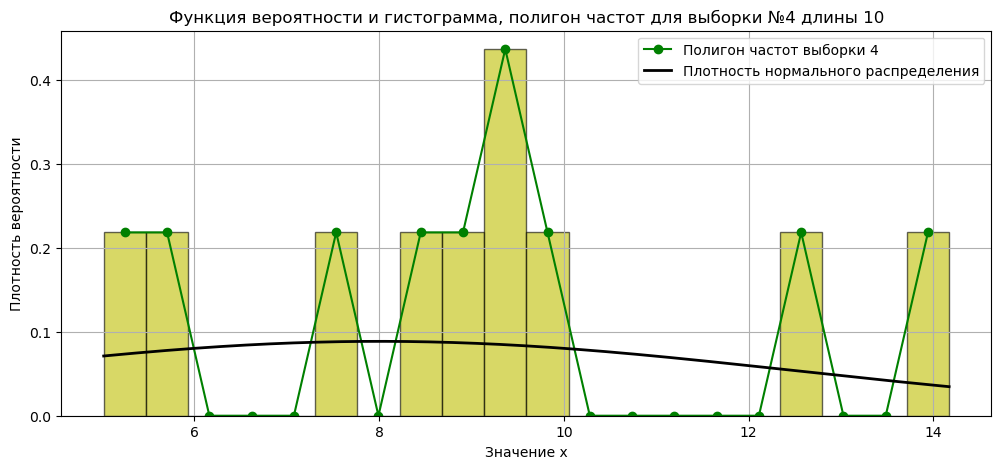

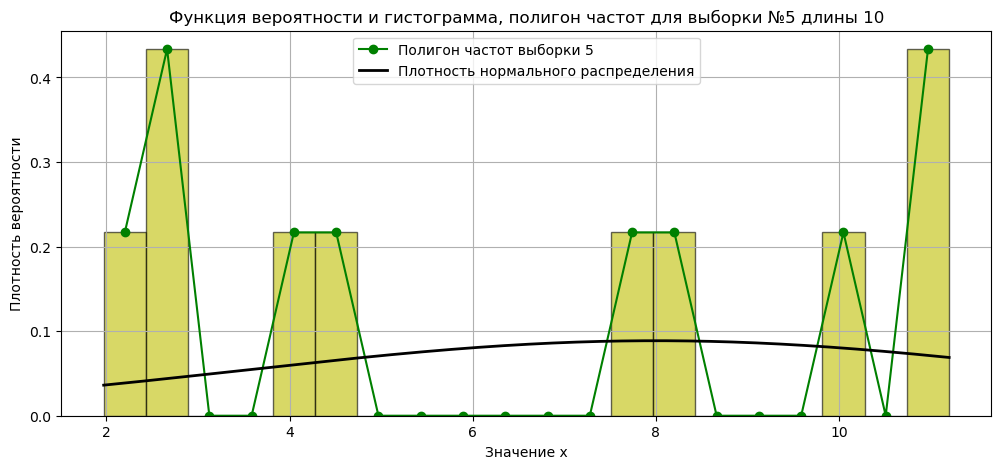

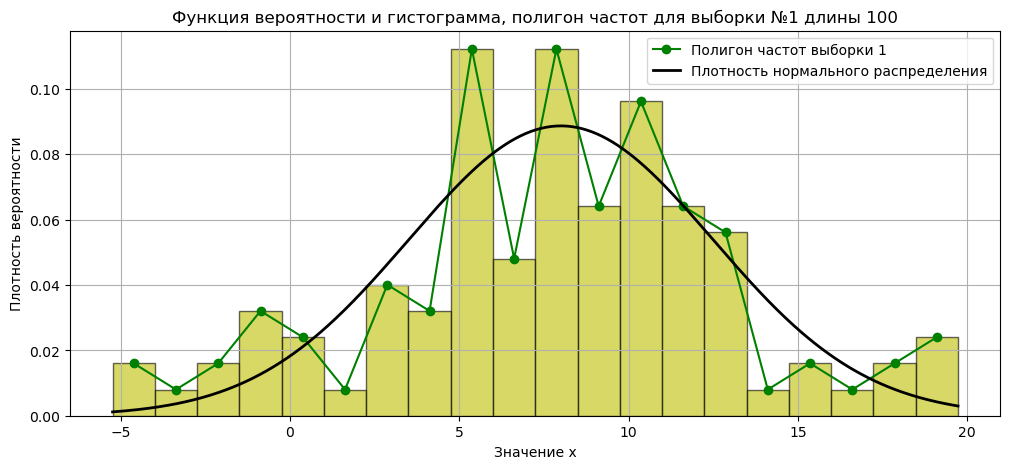

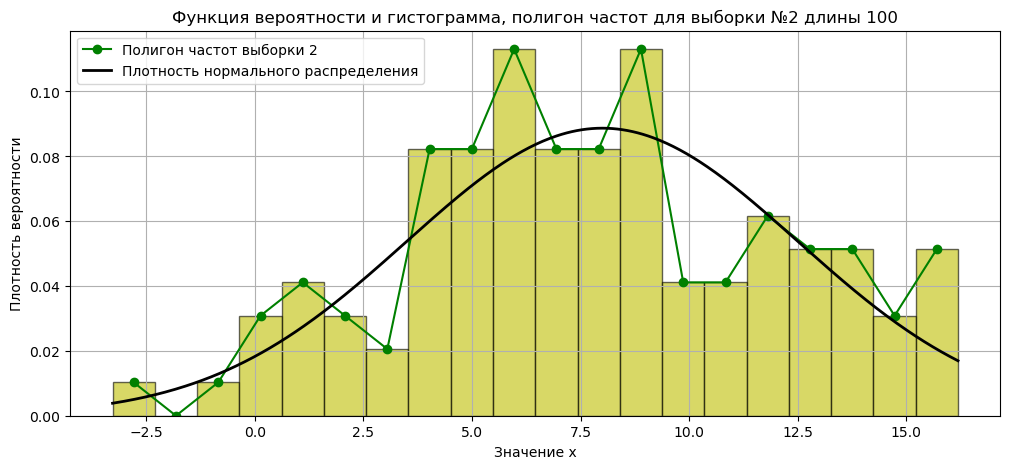

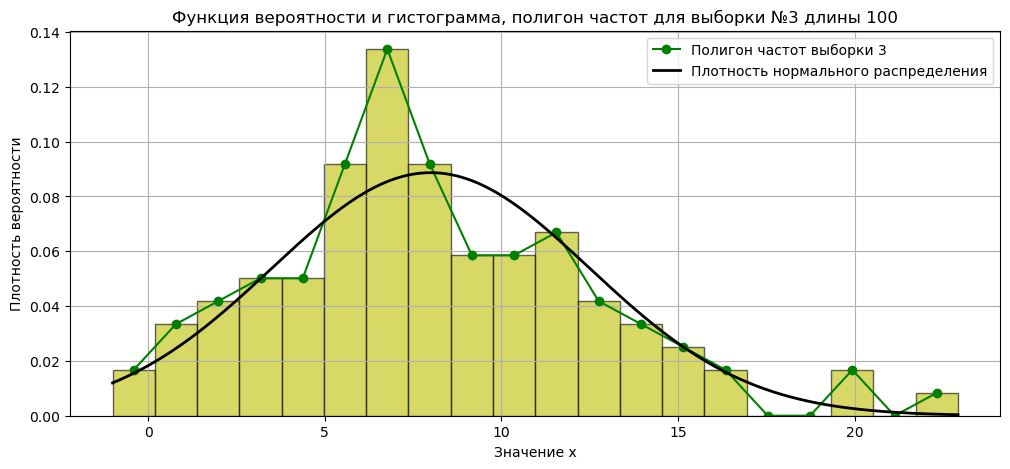

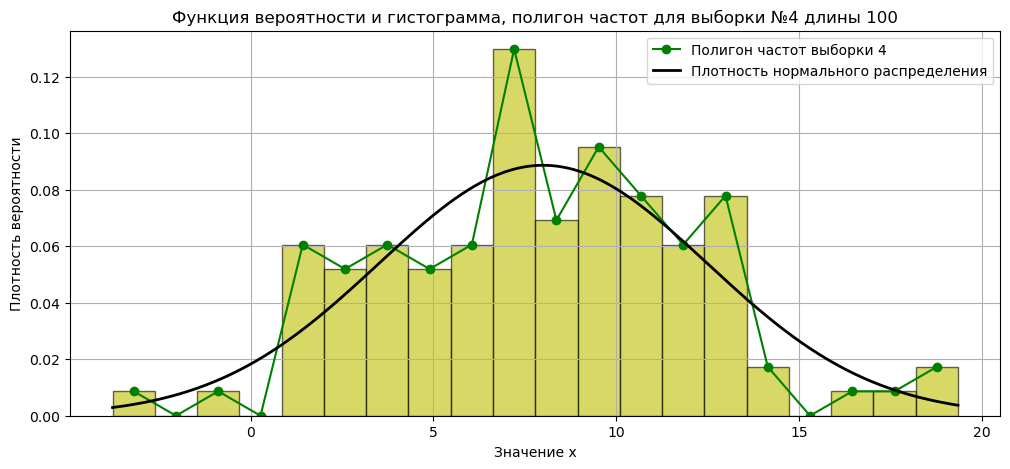

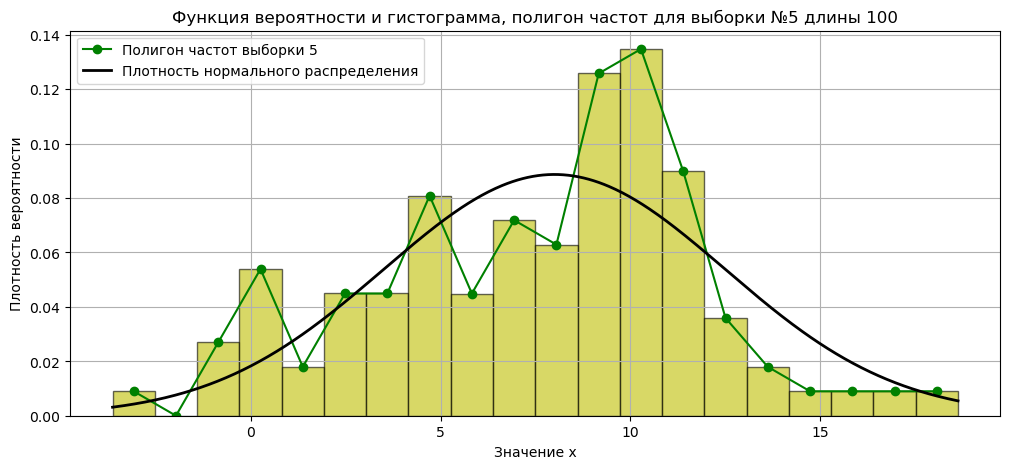

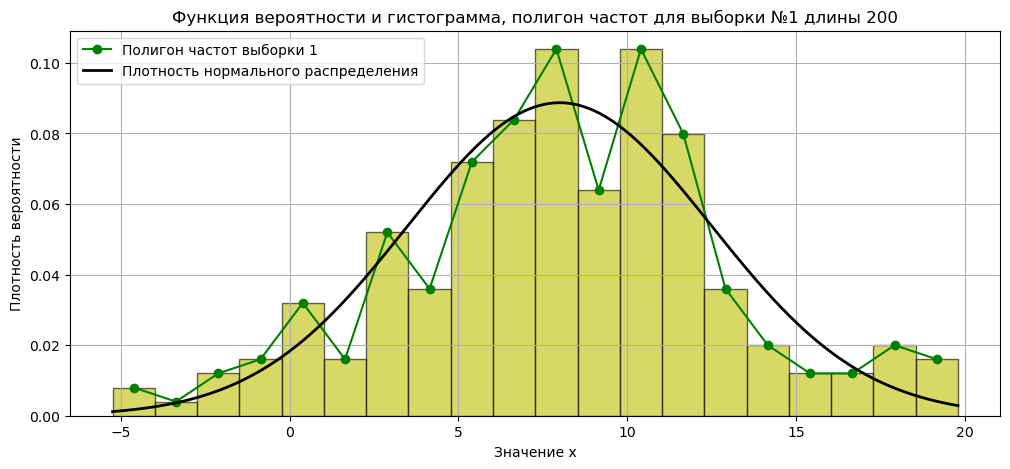

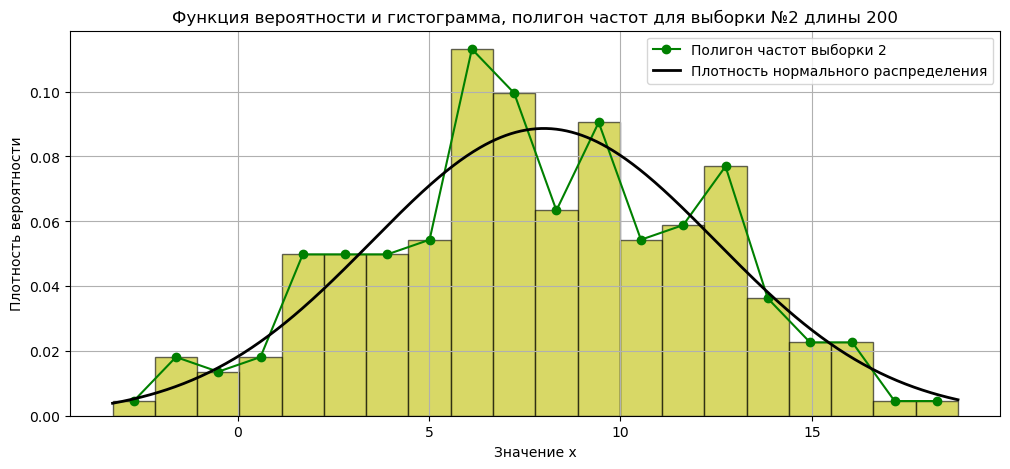

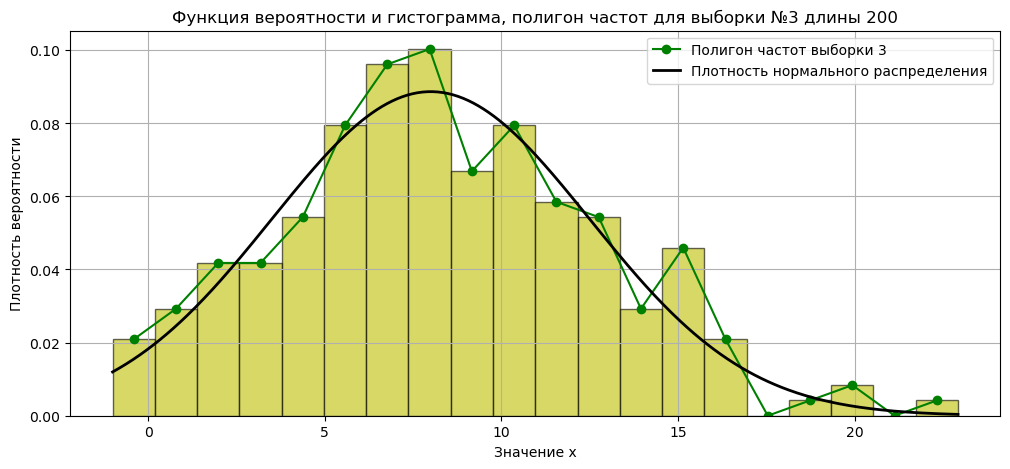

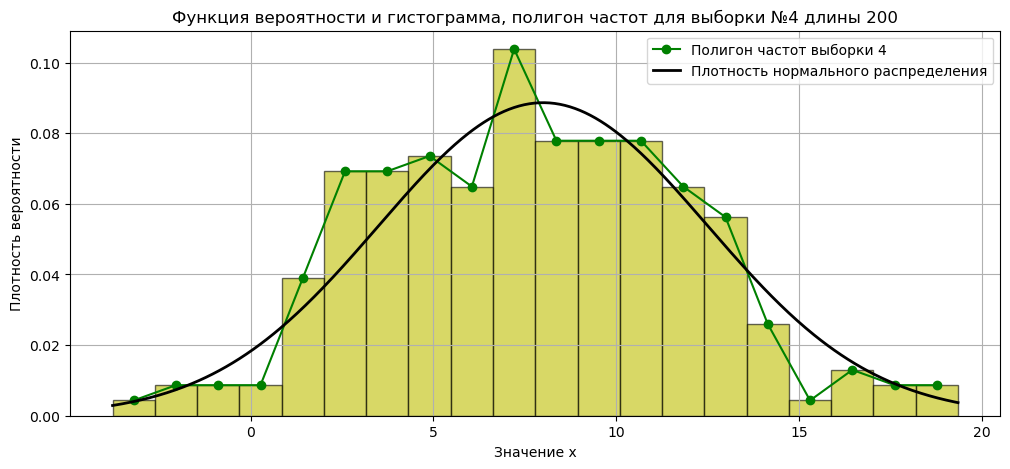

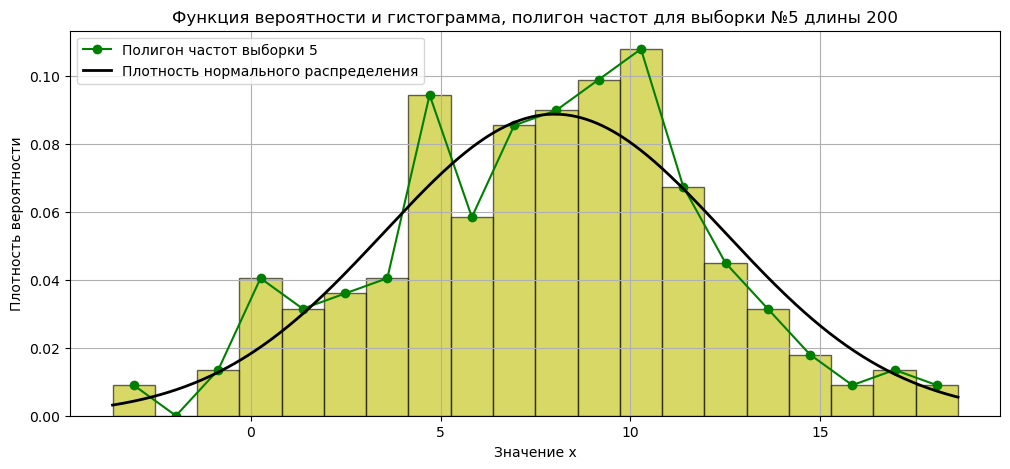

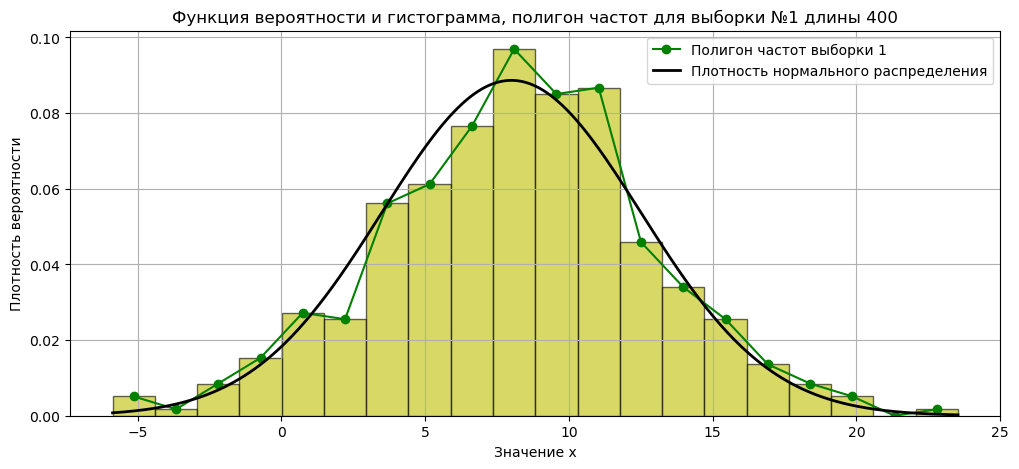

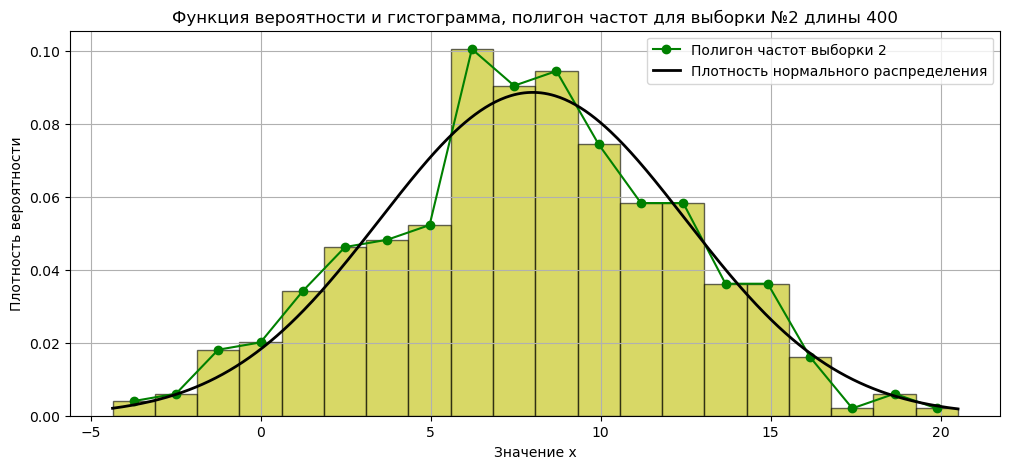

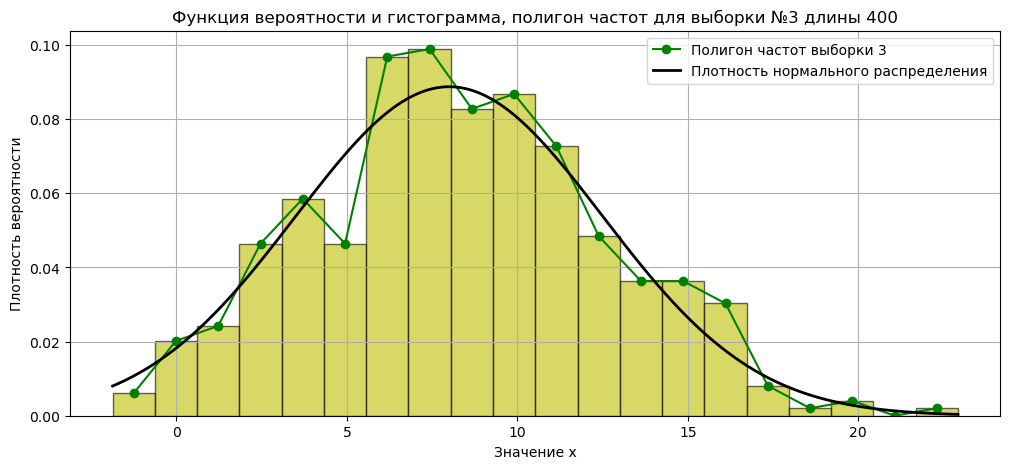

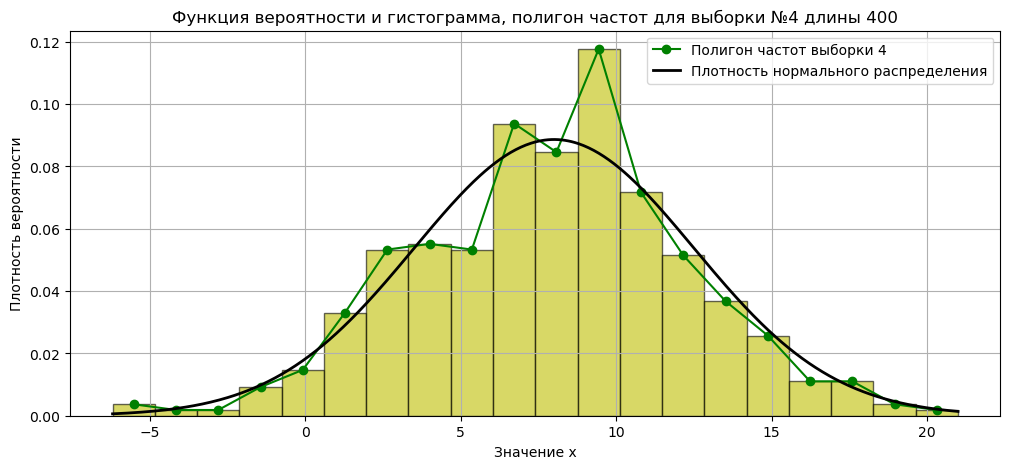

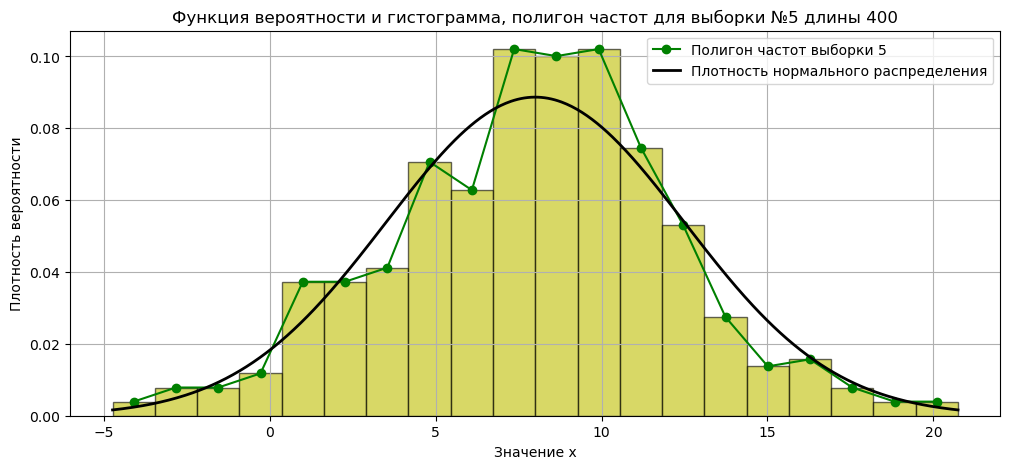

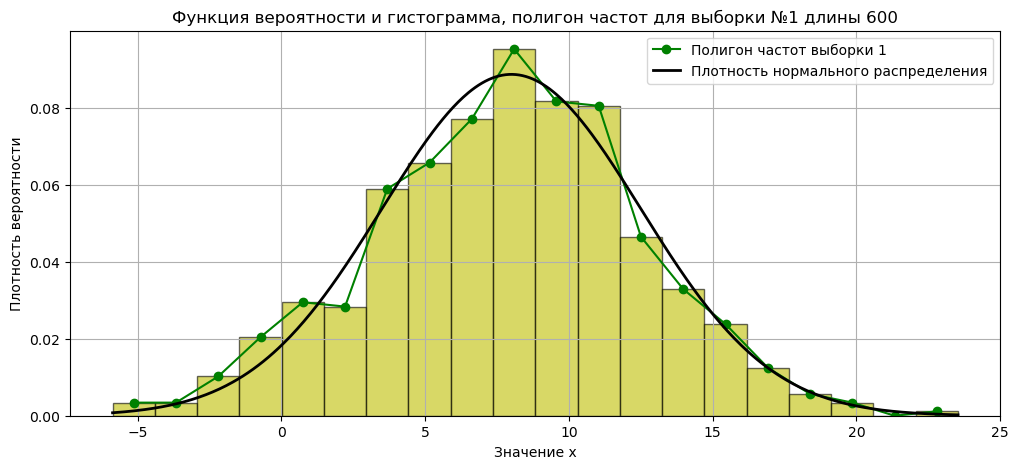

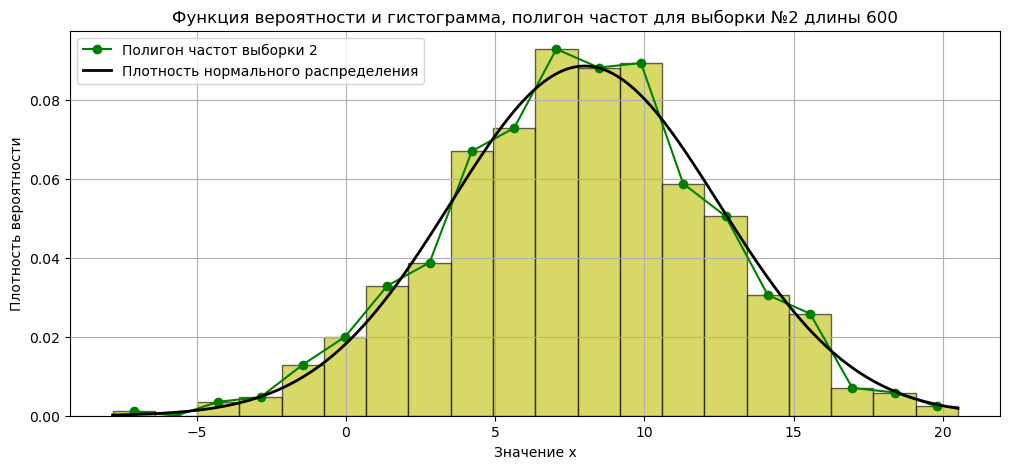

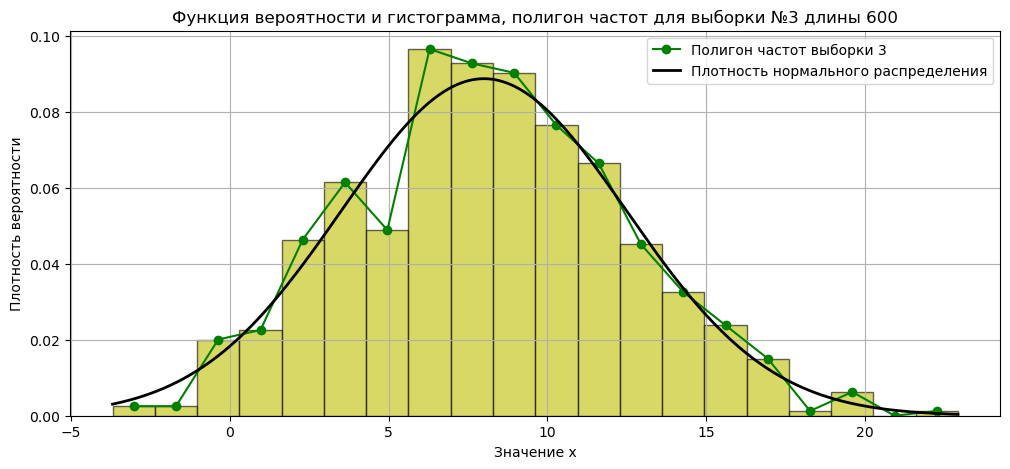

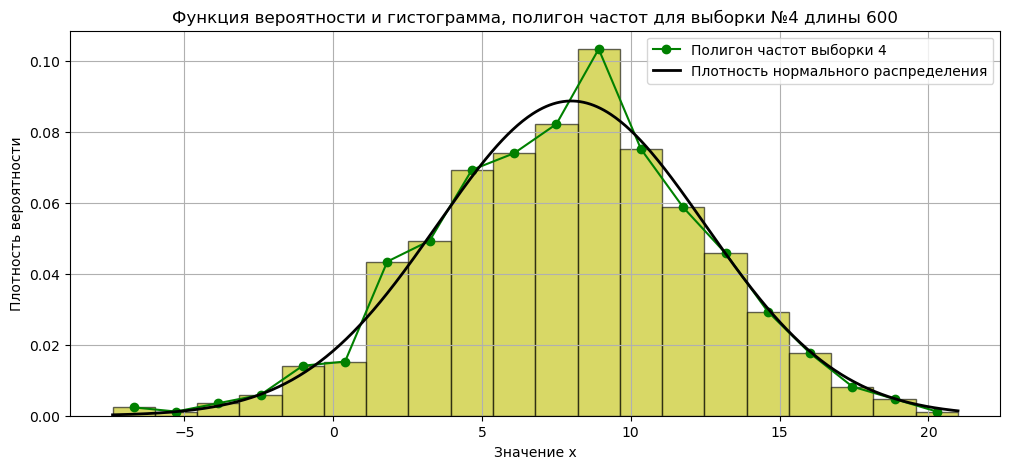

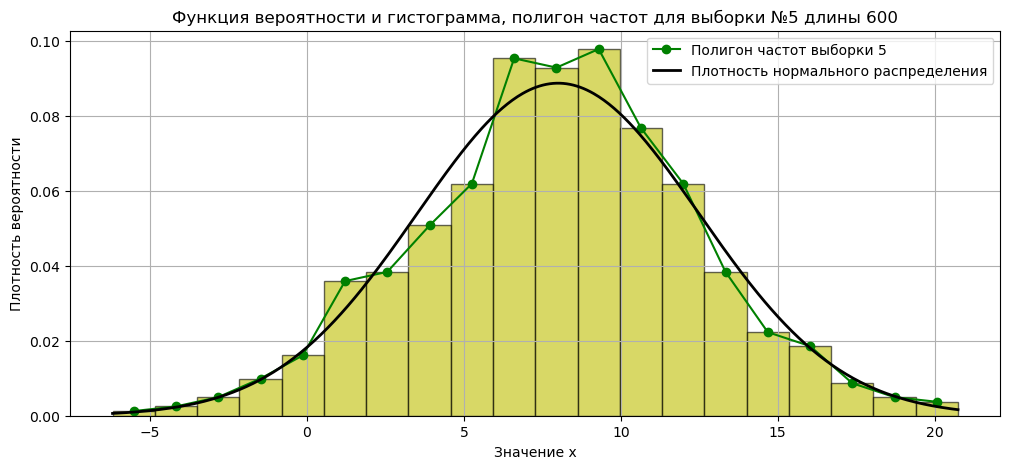

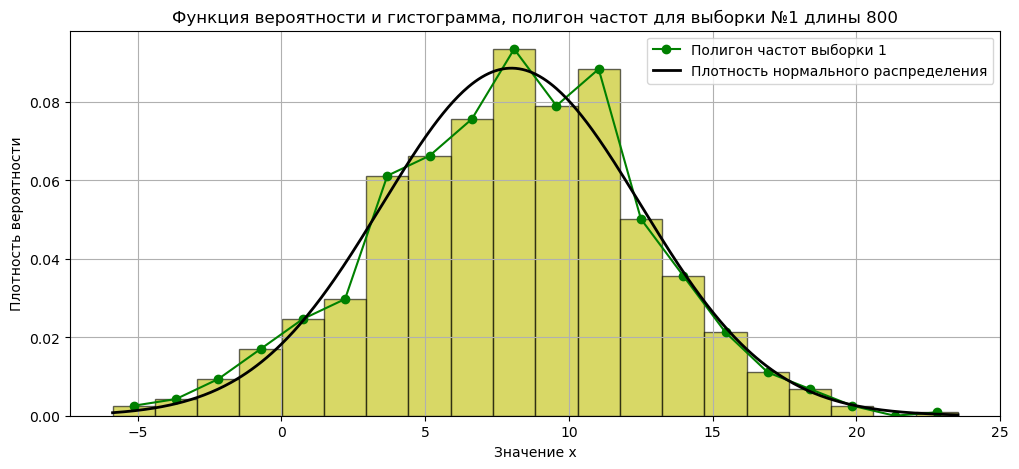

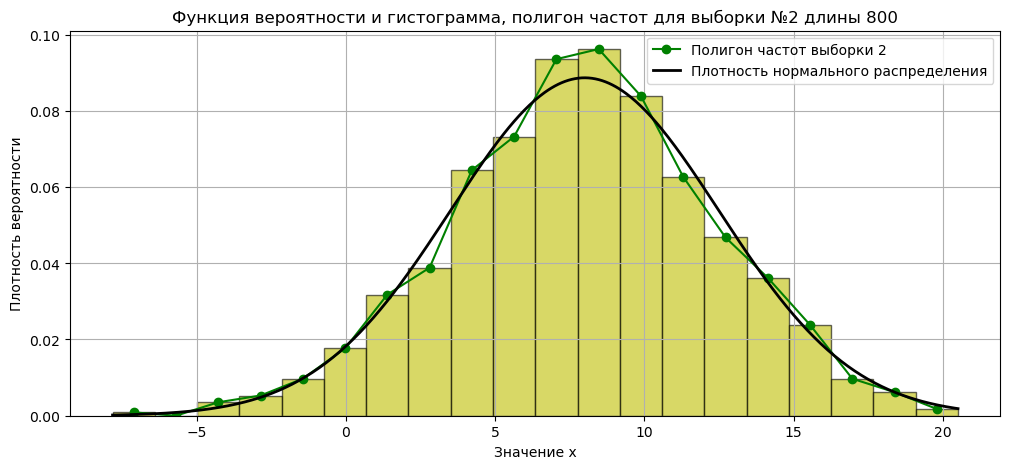

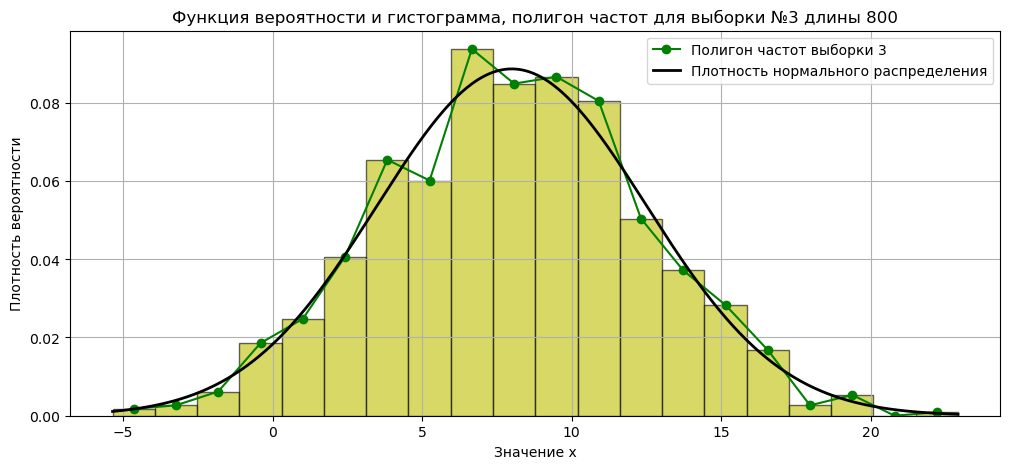

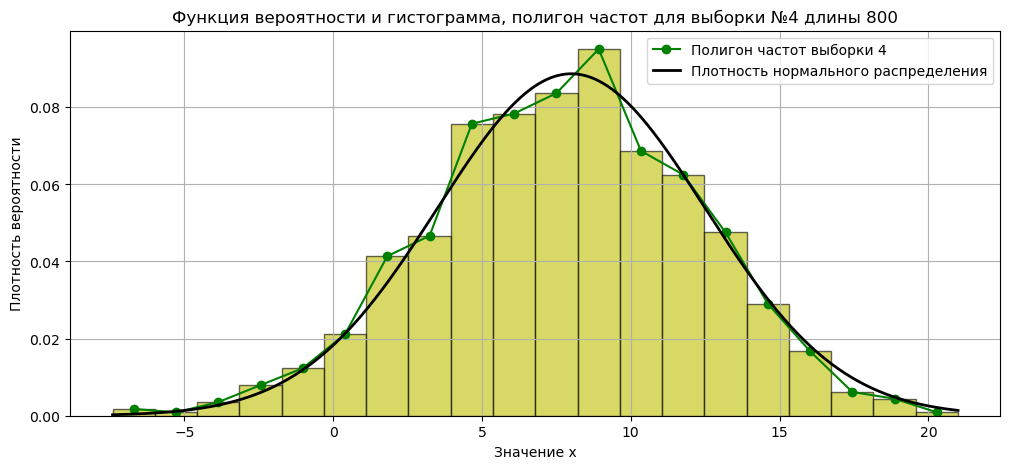

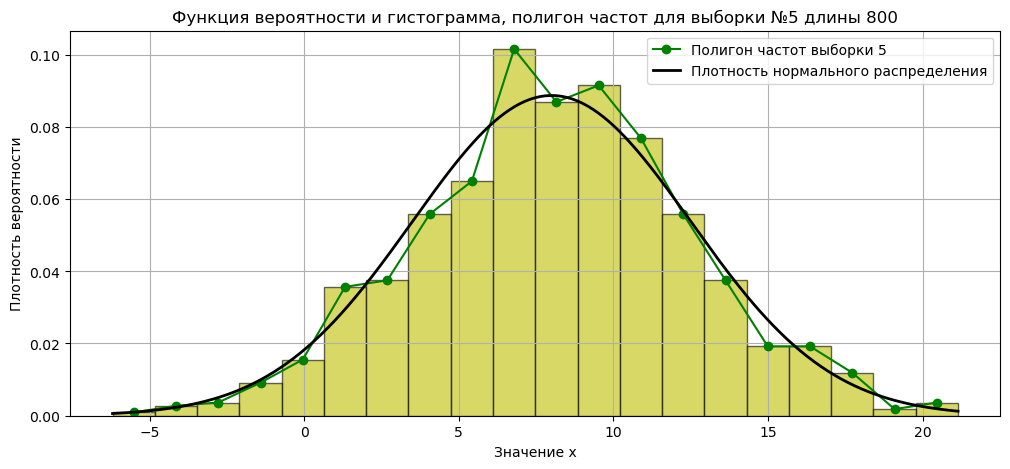

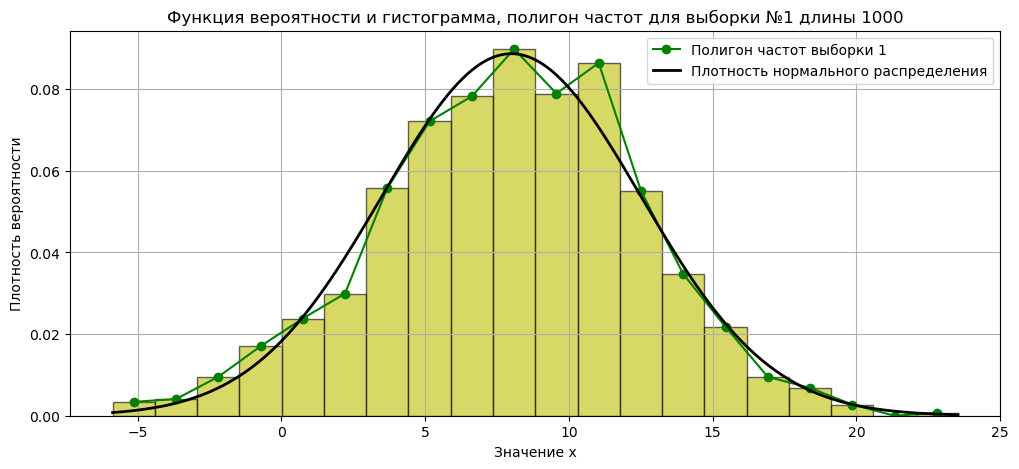

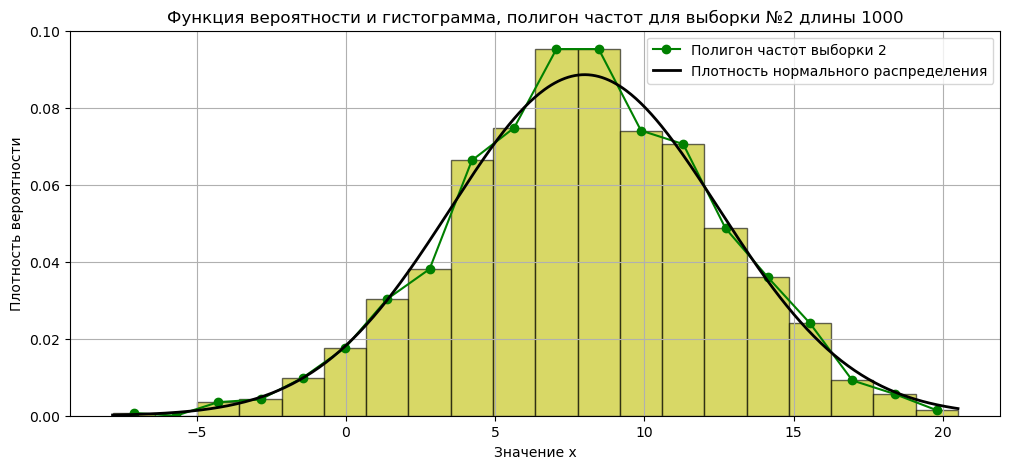

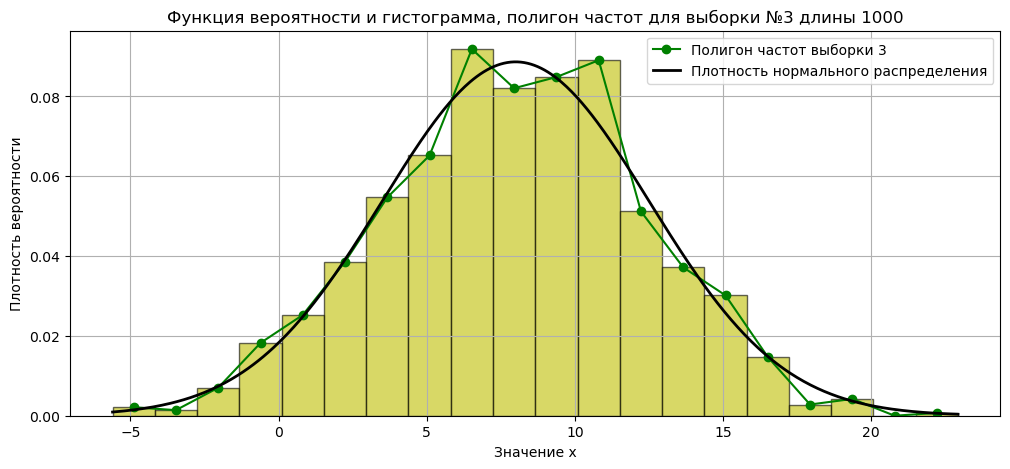

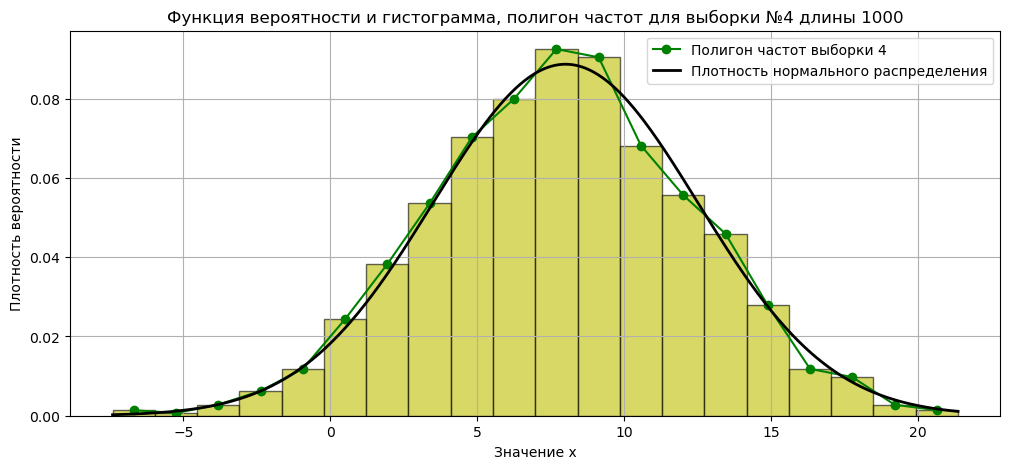

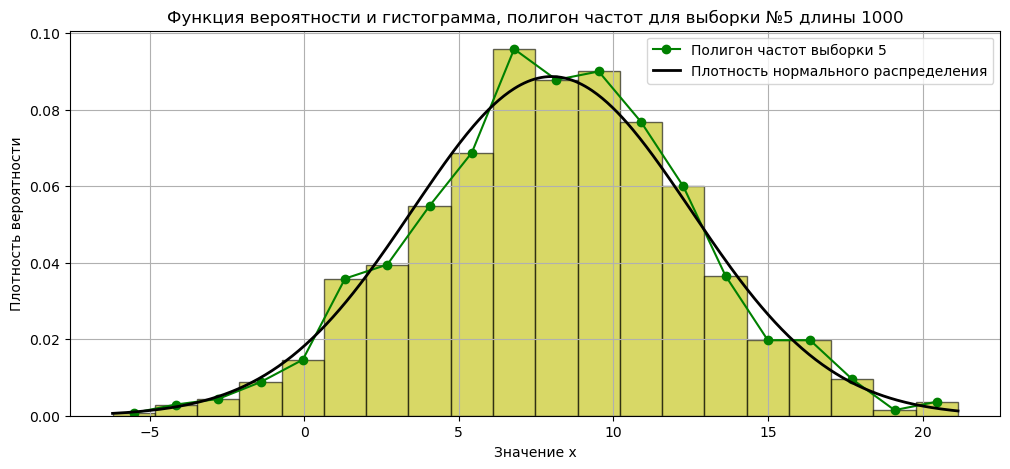

In [45]:
from scipy.stats import norm  # для плотности нормального распределения
#будем использовать встроенную нормализацию
def NormalFrequencyDensity(Uniar, bins=20, theta=None, sigma=None):
    for i, sample in enumerate(Uniar):
        fig, ax = plt.subplots(figsize=(12,5))

        # Гистограмма с плотностью (density=True)
        counts, bin_edges, _ = ax.hist(sample, bins=bins, density=True, alpha=0.6, color='y', edgecolor='black')

        # Полигон частот
        bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
        ax.plot(bin_centers, counts, '-o', color='green', label=f'Полигон частот выборки {i+1}')

        # Теоретическая плотность нормального распределения
        if theta is not None and sigma is not None:
            t_values = np.linspace(min(bin_edges), max(bin_edges), 500)  # плотная сетка для гладкой кривой
            theoretical_values = norm.pdf(t_values, loc=theta, scale=sigma)
            ax.plot(t_values, theoretical_values, color='black', linestyle='-', linewidth=2, label='Плотность нормального распределения')

        ax.set_title(f'Функция вероятности и гистограмма, полигон частот для выборки №{i+1} длины {len(sample)}')
        ax.set_xlabel('Значение x')
        ax.set_ylabel('Плотность вероятности')
        ax.grid(True)
        ax.legend()
        plt.savefig(f"nfreq{len(sample)}_{i+1}.png")
        plt.show()
        plt.close()
        
NormalFrequencyDensity(Normalar5,20,8.0,4.5) 
NormalFrequencyDensity(Normalar10,20,8.0,4.5) 
NormalFrequencyDensity(Normalar100,20,8.0,4.5) 
NormalFrequencyDensity(Normalar200,20,8.0,4.5) 
NormalFrequencyDensity(Normalar400,20,8.0,4.5) 
NormalFrequencyDensity(Normalar600,20,8.0,4.5) 
NormalFrequencyDensity(Normalar800,20,8.0,4.5) 
NormalFrequencyDensity(Normalar1000,20,8.0,4.5) 

**4. Вычисление выборочных моментов**   

### Свойства выборочного среднего  
**Определим, смещенная или нет оценка $\overline{X}$:**  

$M(X) = M\xi$  

$M(\overline{X})=M\left(\frac{1}{n}\sum_{i=1}^n X_i\right) = \frac{1}{n}M\left(\sum_{i=1}^n X_i\right)=\frac{1}{n}\sum_{i=1}^n M(X_i) = \frac{1}{n}\cdot n \cdot M(X_1) = M\xi$  

Следовательно, $\overline{X}$ - **несмещенная** оценка для $M\xi$  

**Определим, состоятельная или нет оценка $\overline{X}$:**  

Оценка $\overline{X}$ является состоятельной(по определению), если:  
$$\forall\varepsilon>0\;\;\;\lim_{n\rightarrow\infty}P\left(\left|\overline{X}-M(X)\right|\geqslant\varepsilon\right)=0$$  

Что буквально является формулировкой закона больших чисел, а значит верно.  

Следовательно, $\overline{X}$ - **состоятельная** оценка для $M\xi$  

### Свойства выборочной дисперсии  

**Определим, смещенная или нет оценка $\overline{S}^2$:**  

$D(X) = D\xi$  

$M(\overline{S}^2) = M\left(\frac{1}{n}\sum_{i=1}^n \left(X_i - \overline{X}\right)^2\right)=\frac{1}{n}M\left(\sum_{i=1}^n \left(X_i - \overline{X}\right)^2\right)=\frac{1}{n}\sum_{i=1}^n M\left(X_i - \overline{X}\right)^2$  

Рассмотрим $M\left(X_i - \overline{X}\right)^2$ :  
$$M\left(X_i - \overline{X}\right)^2 = M\left(X_i^2 - 2X_i\overline{X} + \overline{X}^2\right) = M(X_i^2) - 2M(X_i\overline{X}) + M(\overline{X}^2)$$  

Найдем чему равно $M(X_i^2)$ : $$M(X_i^2) = D(X_i) + (M(X_i))^2 = D(X) + (M(X))^2$$  
Найдем чему равно $M(X_i\overline{X})$ : $$M(X_i\overline{X}) = M\left(X_i\cdot\frac{1}{n}\sum_{j=1}^n X_j\right)=M\left(\frac{1}{n}\sum_{j=1}^n X_iX_j\right) = \frac{1}{n}\sum_{j=1}^n M(X_iX_j)$$  

$$i\neq j\,:\;\;M(X_iX_j)=M(X_i)M(X_j) = (M(X))^2$$  

$$i=j\,:\;\;M(X_iX_i)=M(X_i^2) = D(X) + (M(X))^2$$  
$$M(X_i\overline{X}) = \frac{1}{n}\left(M(X_i^2) + \sum_{i\neq j} M(X_i)M(X_j)\right) = \frac{1}{n}\left(D(X) + (M(X))^2 + (n-1)(M(x))^2\right) = \frac{D(X)}{n} + (M(X))^2$$  

Найдем чему равно $M(\overline{X}^2)$ : $$M(\overline{X}^2) = D(\overline{X}) + (M(\overline{X}))^2 = \frac{D(X)}{n} + (M(X))^2$$  

Тогда: $$M(X_i - \overline{X})^2 = D(X) + (M(X))^2 - 2\frac{D(X)}{n} - 2(M(X))^2 + \frac{D(X)}{n} + (M(X))^2 = \frac{n-1}{n}D(X)$$  

$$M(\overline{S}^2) = \frac{1}{n}\cdot n\cdot\frac{n-1}{n}D(X)=\frac{n-1}{n}D(X)\neq D(X)$$  

Следовательно, $\overline{S}^2$ - **смещенная** оценка для $D(X)$  

**Определим, состоятельная или нет оценка $\overline{S}^2$:**  
$$\overline{S}^2 = \frac{1}{n}\sum_{i=1}^n \left(X_i - \overline{X}\right)^2$$  

Оценка $\overline{S}^2$ является состоятельной(по определению), если:  
$$\forall\varepsilon>0\;\;\;\lim_{n\rightarrow\infty}P\left(\left|\frac{1}{n}\sum_{i=1}^n \left(X_i - \overline{X}\right)^2-D(X)\right|\geqslant\varepsilon\right)=0$$  
При этом, по закону больших чисел верно: $$\forall\varepsilon_1>0\;\;\;\lim_{n\rightarrow\infty}P\left(\left|\frac{1}{n}\sum_{i=1}^n \left(X_i - \overline{X}\right)^2-\frac{n-1}{n}D(X)\right|\geqslant\varepsilon_1\right)=0$$  
Тогда очевидно верно: $$\forall\varepsilon_1>0\;\;\;\lim_{n\rightarrow\infty}P\left(\left|\frac{1}{n}\sum_{i=1}^n \left(X_i - \overline{X}\right)^2-D(X)\right|\geqslant\varepsilon_1+\frac{D(X)}{n}\right)=0$$  
А значит: $$\forall\varepsilon_1>0,\ \varepsilon=2\varepsilon_1\;\;\;\lim_{n\rightarrow\infty}P\left(\left|\frac{1}{n}\sum_{i=1}^n \left(X_i - \overline{X}\right)^2-D(X)\right|\geqslant\varepsilon\geqslant\varepsilon_1+\frac{D(X)}{n}\right)=0$$  
Таким образом: $$\forall\varepsilon>0\;\;\;\lim_{n\rightarrow\infty}P\left(\left|\frac{1}{n}\sum_{i=1}^n \left(X_i - \overline{X}\right)^2-D(X)\right|\geqslant\varepsilon\right)=0$$  
Следовательно, $\overline{S}^2$ - **состоятельная** оценка для $D(X)$   

*а) Дискретное равномерное II*  
[Код для подсчета выборочного среднего и выборочной дисперсии](#Unimean)  
Математическое ожидание равно 185.5  
Дисперсия равна 971.9166666666666  

Рассмотрим выборочное среднее и выборочную дисперсию на выборках №2, №4:  
$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 5  

Выборка номер 2:  
Выборочное среднее 189.6. Разница с матожиданием: 4.099999999999994  
Выборочная дисперсия 1232.6399999999999. Разница с дисперсией: 260.72333333333324  

Выборка номер 4:  
Выборочное среднее 188.4. Разница с матожиданием: 2.9000000000000057  
Выборочная дисперсия 1497.4399999999998. Разница с дисперсией: 525.5233333333332  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 10    

Выборка номер 2:  
Выборочное среднее 190.4. Разница с матожиданием: 4.900000000000006  
Выборочная дисперсия 1166.2400000000002. Разница с дисперсией: 194.3233333333336  

Выборка номер 4:  
Выборочное среднее 193.2. Разница с матожиданием: 7.699999999999989  
Выборочная дисперсия 911.3599999999999. Разница с дисперсией: 60.55666666666673  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 100    

Выборка номер 2:  
Выборочное среднее 187.87. Разница с матожиданием: 2.3700000000000045  
Выборочная дисперсия 984.8330999999995. Разница с дисперсией: 12.916433333332861  

Выборка номер 4:  
Выборочное среднее 185.3. Разница с матожиданием: 0.19999999999998863  
Выборочная дисперсия 832.9099999999999. Разница с дисперсией: 139.00666666666677  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 200  

Выборка номер 2:  
Выборочное среднее 185.065. Разница с матожиданием: 0.4350000000000023  
Выборочная дисперсия 952.8907749999997. Разница с дисперсией: 19.025891666666894  

Выборка номер 4:  
Выборочное среднее 183.555. Разница с матожиданием: 1.9449999999999932  
Выборочная дисперсия 954.416975. Разница с дисперсией: 17.49969166666665  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 400    

Выборка номер 2:  
Выборочное среднее 185.0725. Разница с матожиданием: 0.4275000000000091  
Выборочная дисперсия 974.0272437499999. Разница с дисперсией: 2.1105770833332826  

Выборка номер 4:  
Выборочное среднее 185.245. Разница с матожиданием: 0.25499999999999545  
Выборочная дисперсия 987.5999749999993. Разница с дисперсией: 15.683308333332661  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 600       

Выборка номер 2:  
Выборочное среднее 185.38333333333333. Разница с матожиданием: 0.11666666666667425  
Выборочная дисперсия 975.5297222222217. Разница с дисперсией: 3.6130555555550927  

Выборка номер 4:  
Выборочное среднее 184.56166666666667. Разница с матожиданием: 0.9383333333333326  
Выборочная дисперсия 990.0861972222217. Разница с дисперсией: 18.16953055555507  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 800     

Выборка номер 2:  
Выборочное среднее 186.1275. Разница с матожиданием: 0.6274999999999977  
Выборочная дисперсия 975.7512437499994. Разница с дисперсией: 3.8345770833327606  

Выборка номер 4:  
Выборочное среднее 185.1475. Разница с матожиданием: 0.35249999999999204  
Выборочная дисперсия 995.0832437499995. Разница с дисперсией: 23.166577083332868  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 1000    

Выборка номер 2:  
Выборочное среднее 185.627. Разница с матожиданием: 0.12700000000000955  
Выборочная дисперсия 987.0718709999998. Разница с дисперсией: 15.155204333333131  

Выборка номер 4:  
Выборочное среднее 184.759. Разница с матожиданием: 0.7410000000000139  
Выборочная дисперсия 986.3769190000011. Разница с дисперсией: 14.460252333334438  


*б) Нормальное I*  
[Код для подсчета выборочного среднего и выборочной дисперсии](#Normalmean)    

Математическое ожидание равно 8.0
Дисперсия равна 20.25

Рассмотрим выборочное среднее и выборочную дисперсию на выборках №1, №3:  
$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 5  

Выборка номер 1:  
Выборочное среднее 5.601380550858069. Разница с матожиданием: 2.398619449141931  
Выборочная дисперсия 13.176076517844683. Разница с дисперсией: 7.073923482155317  

Выборка номер 3:  
Выборочное среднее 8.47393231590044. Разница с матожиданием: 0.4739323159004396  
Выборочная дисперсия 6.174753760499467. Разница с дисперсией: 14.075246239500533  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 10    

Выборка номер 1:  
Выборочное среднее 6.963419492257286. Разница с матожиданием: 1.0365805077427144  
Выборочная дисперсия 14.648983946056457. Разница с дисперсией: 5.6010160539435425  

Выборка номер 3:  
Выборочное среднее 7.92887060629309. Разница с матожиданием: 0.07112939370690974  
Выборочная дисперсия 8.201930023961033. Разница с дисперсией: 12.048069976038967  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 100    

Выборка номер 1:  
Выборочное среднее 7.525564227895258. Разница с матожиданием: 0.47443577210474164    
Выборочная дисперсия 19.482994594581342. Разница с дисперсией: 0.7670054054186579    

Выборка номер 3:  
Выборочное среднее 7.658262929416686. Разница с матожиданием: 0.3417370705833136  
Выборочная дисперсия 18.351435973921628. Разница с дисперсией: 1.8985640260783718  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 200  

Выборка номер 1:  
Выборочное среднее 7.570358991162022. Разница с матожиданием: 0.4296410088379776  
Выборочная дисперсия 19.47254874424804. Разница с дисперсией: 0.7774512557519593  

Выборка номер 3:  
Выборочное среднее 7.975398237086613. Разница с матожиданием: 0.024601762913387226  
Выборочная дисперсия 20.575277234393266. Разница с дисперсией: 0.3252772343932655  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 400    

Выборка номер 1:  
Выборочное среднее 7.7726985002841005. Разница с матожиданием: 0.22730149971589952  
Выборочная дисперсия 18.97749156636941. Разница с дисперсией: 1.2725084336305912  

Выборка номер 3:  
Выборочное среднее 7.764571373929827. Разница с матожиданием: 0.23542862607017323   
Выборочная дисперсия 21.74674494524561. Разница с дисперсией: 1.4967449452456094  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 600       

Выборка номер 1:  
Выборочное среднее 7.970884147879057. Разница с матожиданием: 0.029115852120942698  
Выборочная дисперсия 20.717560471407985. Разница с дисперсией: 0.4675604714079853  

Выборка номер 3:  
Выборочное среднее 7.930631560574764. Разница с матожиданием: 0.06936843942523563   
Выборочная дисперсия 21.791614753967732. Разница с дисперсией: 1.5416147539677318  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 800      

Выборка номер 1:  
Выборочное среднее 7.977616776036711. Разница с матожиданием: 0.02238322396328929  
Выборочная дисперсия 20.37300723364816. Разница с дисперсией: 0.1230072336481598  

Выборка номер 3:  
Выборочное среднее 8.063701656107666. Разница с матожиданием: 0.06370165610766598  
Выборочная дисперсия 20.99329556287522. Разница с дисперсией: 0.7432955628752183  

$\bullet$ Выборочное среднее и выборочная дисперсия для выборок объема 1000    

Выборка номер 1:  
Выборочное среднее 8.039872629578383. Разница с матожиданием: 0.03987262957838311  
Выборочная дисперсия 20.160594575153155. Разница с дисперсией: 0.089405424846845  

Выборка номер 3:  
Выборочное среднее 7.980648498044882. Разница с матожиданием: 0.01935150195511781  
Выборочная дисперсия 21.391319717409687. Разница с дисперсией: 1.1413197174096865  


# <a id="Unimean"> Вычисление выборочных моментов для дискретного равномерного II распредения</a>

In [48]:
E, D_ = 371/2, 11663/12
print(f'Математическое ожидание равно {E}')
print(f'Дисперсия равна {D_}')
print('\n-----\n')
def MeanVarience(Uniar):
    print(f'Выборочное среднее и выборочная дисперсия для выборок объема {len(Uniar[0])}')
    for i in range(5):
        # Считаем и выводим выборочное среднее и выборочную дисперсию
        x = sum(Uniar[i]) / len(Uniar[i])
        print(f'Выборка номер {i + 1}:\nВыборочное среднее {x}. Разница с матожиданием: {abs(x - E)}')
        print(f'Выборочная дисперсия {sum([(elem - x) ** 2 for elem in Uniar[i]]) / len(Uniar[i])}. Разница с дисперсией: {abs(sum([(elem - x) ** 2 for elem in Uniar[i]]) / len(Uniar[i]) - D_)}')
        print()
    print(('-----\n' if len(Uniar[i]) != 1000 else ''))

MeanVarience(Uniar5)
MeanVarience(Uniar10)
MeanVarience(Uniar100)
MeanVarience(Uniar200)
MeanVarience(Uniar400)
MeanVarience(Uniar600)
MeanVarience(Uniar800)
MeanVarience(Uniar1000)

Математическое ожидание равно 185.5
Дисперсия равна 971.9166666666666

-----

Выборочное среднее и выборочная дисперсия для выборок объема 5
Выборка номер 1:
Выборочное среднее 192.6. Разница с матожиданием: 7.099999999999994
Выборочная дисперсия 1271.4399999999998. Разница с дисперсией: 299.5233333333332

Выборка номер 2:
Выборочное среднее 198.2. Разница с матожиданием: 12.699999999999989
Выборочная дисперсия 994.96. Разница с дисперсией: 23.043333333333408

Выборка номер 3:
Выборочное среднее 196.8. Разница с матожиданием: 11.300000000000011
Выборочная дисперсия 1121.3600000000001. Разница с дисперсией: 149.4433333333335

Выборка номер 4:
Выборочное среднее 199.6. Разница с матожиданием: 14.099999999999994
Выборочная дисперсия 730.64. Разница с дисперсией: 241.27666666666664

Выборка номер 5:
Выборочное среднее 185.6. Разница с матожиданием: 0.09999999999999432
Выборочная дисперсия 451.43999999999994. Разница с дисперсией: 520.4766666666667

-----

Выборочное среднее и выборочная ди

# <a id="Normalmean"> Вычисление выборочных моментов для нормального I распредения</a>

In [50]:
En, Dn_ = 8.0, 4.5**2
print(f'Математическое ожидание равно {En}')
print(f'Дисперсия равна {Dn_}')
print('\n-----\n')
def NMeanVarience(Normalar):
    print(f'Выборочное среднее и выборочная дисперсия для выборок объема {len(Normalar[0])}')
    for i in range(5):
        # Считаем и выводим выборочное среднее и выборочную дисперсию
        x = sum(Normalar[i]) / len(Normalar[i])
        print(f'Выборка номер {i + 1}:\nВыборочное среднее {x}. Разница с матожиданием: {abs(x - En)}')
        print(f'Выборочная дисперсия {sum([(elem - x) ** 2 for elem in Normalar[i]]) / len(Normalar[i])}. Разница с дисперсией: {abs(sum([(elem - x) ** 2 for elem in Normalar[i]]) / len(Normalar[i]) - Dn_)}')
        print()
    print(('-----\n' if len(Normalar[i]) != 1000 else ''))

NMeanVarience(Normalar5)
NMeanVarience(Normalar10)
NMeanVarience(Normalar100)
NMeanVarience(Normalar200)
NMeanVarience(Normalar400)
NMeanVarience(Normalar600)
NMeanVarience(Normalar800)
NMeanVarience(Normalar1000)




Математическое ожидание равно 8.0
Дисперсия равна 20.25

-----

Выборочное среднее и выборочная дисперсия для выборок объема 5
Выборка номер 1:
Выборочное среднее 2.1416193376137693. Разница с матожиданием: 5.858380662386231
Выборочная дисперсия 21.617933225790686. Разница с дисперсией: 1.3679332257906864

Выборка номер 2:
Выборочное среднее 8.980718624977735. Разница с матожиданием: 0.9807186249777349
Выборочная дисперсия 2.7439610231055043. Разница с дисперсией: 17.506038976894494

Выборка номер 3:
Выборочное среднее 7.3885877911664295. Разница с матожиданием: 0.6114122088335705
Выборочная дисперсия 11.046268745285925. Разница с дисперсией: 9.203731254714075

Выборка номер 4:
Выборочное среднее 9.201157439531125. Разница с матожиданием: 1.2011574395311246
Выборочная дисперсия 7.768019601746502. Разница с дисперсией: 12.481980398253498

Выборка номер 5:
Выборочное среднее 7.356877686464065. Разница с матожиданием: 0.643122313535935
Выборочная дисперсия 11.727565855181686. Разница с ди

# <a id="title3">Домашнее задание 3. Построение точечных оценок параметра распределения</a>  
$1.$ Получение оценок методом моментов и методом максимального правдоподобия  
*а) Дискретное равномерное II*  
$\bullet \; L(\bar x, \theta)=\prod\limits_{i=1}^n \frac1{\theta} I[x_i \geq a] I[x_i \leq a+\theta-1]=\frac1{\theta^n}I[x_{(1)} \geq a] I[x_{(n)} \leq a+\theta-1]$. Тогда $I[x_{(n)} \leq a+\theta-1]=I[\theta \geq x_{(n)}- a+1]$.
Максимум функции правдоподобия достигается при макисмальном $\frac1{\theta^n}$, для этого $\theta$ должна принимать наименьшее возможное значение, то есть $\hat \theta_{О.М.П.}=X_{(n)}- a+1$  

$\bullet \; Ex=a+\frac{\theta-1}{2}=g(\theta)$  
$g^{-1}(\bar X)=\hat \theta_{О.М.М.}$  
$g(z)=a+\frac{z-1}{2}$  
$y(\theta)=a+\frac{\theta-1}{2}$  
$g^{-1}(\theta)=2\theta-2a+1$  
$\hat \theta_{О.М.М.}=g^{-1}(\bar X)=2\bar X -2a+1$  

*б) Нормальное I*  
$\bullet \; L(\bar x, \theta)=\prod\limits_{i=1}^n \frac1{\sigma \sqrt{2\pi}} exp\left\{-\frac{(x_i-\theta)^2}{2\sigma^2} \right\}=\frac1{\sigma^n (2\pi)^{\frac{n}{2}}} e^{-\frac1{2\sigma^2} \sum\limits_{i=1}^n (x_i-\theta)^2}=\frac1{\sigma^n (2\pi)^{\frac{n}{2}}} e^{-\frac1{2\sigma^2}(\sum\limits_{i=1}^n x_i^2 -2\theta \sum\limits_{i=1}^n x_i +n \theta^2) }$  
$\ln {L(\bar x, \theta)}=-\ln{\sigma^n (2\pi)^{\frac{n}{2}}}-\frac1{2\sigma^2}(\sum\limits_{i=1}^n x_i^2 -2\theta \sum\limits_{i=1}^n x_i +n \theta^2)$ 
Берем производную по $\theta$ и приравниваем к нулю:  
$\frac {\partial \ln {L(\bar x, \theta)}} {\partial \theta}=\frac1{\sigma^2}\sum\limits_{i=1}^n x_i-\frac{n}{\sigma^2} \theta$  
$\frac1{\sigma^2}\sum\limits_{i=1}^n x_i-\frac{n}{\sigma^2} \theta=0$, следовательно, $\hat \theta_{О.М.П.}=\bar X$    

$\bullet \; Ex=\theta=g(\theta)$  
$g^{-1}(\bar x)=\hat \theta_{О.М.М.}$  
$g(z)=z$  
$g^{-1}(\theta)=\theta$   
$\hat \theta_{О.М.М.}=g^{-1}(\bar X)=\bar X$  

$2.$ Поиск оптимальных оценок  
*а) Дискретное равномерное II*  
Будем искать оптимальную оценку для $\theta$.  
$\underline {1 \; шаг}$ Поиск достаточной статистики  
$L(\bar x, \theta)=\prod\limits_{i=1}^n \frac1{\theta} I[x_i \geq a] I[x_i \leq a+\theta-1]=\frac1{\theta^n}I[x_{(1)} \geq a] I[x_{(n)} \leq a+\theta-1]$  $h(x)=\frac1{\theta^n}I[x_{(1)} \geq a]$, $g(T(x),\theta)=I[x_{(n)} \leq a+\theta-1]$, тогда по критерию факторизации статистика $T(x)=X_{(n)}$ является достаточной.    
$\underline {2 \; шаг}$ Проверка на полноту  
$P_{X_{(n)}}(x)=(\frac{x-a+1}{\theta})^n-(\frac{x-a}{\theta})^n=\frac{(x-a+1)^n-(x-a)^n}{\theta^n}$  
$E(g(X_{(n)}))=\sum\limits_{m=a}^{a+\theta-1} g(m) \frac{(m-a+1)^n-(m-a)^n}{\theta^n}=0$. Домножим на $\theta^n \; (\theta \neq 0)$:  
$\sum\limits_{m=a}^{a+\theta-1} g(m) ((m-a+1)^n-(m-a)^n)=0$  
Метод математической индукции:  
$1) \theta=1$   
$g(a)((a-a+1)^n-(a-a)^n)=g(a)=0$, следовательно, $g(X_{(n)})=0 \; \forall \theta$  
$2)$ Пусть для некоторого $r \geq 1 \; g(a)=g(a+2)=\ldots=g(a+r-1)=0$. Возьмём $\theta=r+1$. Тогда в сумме нулевыми являются первые $r$ слагаемых, и остается член с $m=a+r$:  
$g(a+r)((r+1)^n-r^n)=0$  
$(r+1)^n-r^n > 0 \Rightarrow g(a+r)=0$.  
По ММИ получаем, что $g(m)=0 \; \forall m \in \{a, \ldots, a+\theta-1\}$ $\Rightarrow X_{(n)}$ - полная достаточная статистика.  
$\underline {3 \; шаг}$ Ищем функцию $\phi(X_{(n)})$ от полной достаточной статистики - она и будет оптимальной оценкой параметра $\theta$  
$E(\phi(X_{(n)}))=\theta \; \forall \theta$  
$\sum\limits_{m=a}^{a+\theta-1} \phi(m) \frac{(m-a+1)^n-(m-a)^n}{\theta^n}=\theta$  
$\sum\limits_{m=a}^{a+\theta-1} \phi(m) ((m-a+1)^n-(m-a)^n)=\theta^{n+1}$  
Замена: $y=m-a+1$, $\psi(y)=\phi(a+y-1)$  
$\sum\limits_{y=1}^\theta \psi(y)(y^n-(y-1)^n)=\theta^{n+1}$ (1). Так как это равенство верно $\forall \theta$, то для $\theta-1$:   
$\sum\limits_{y=1}^{\theta-1} \psi(y)(y^n-(y-1)^n)=(\theta-1)^{n+1}$ (2)  
Вычтем из (1) равенства (2) и получим:  
$\psi(\theta)(\theta^n-(\theta-1)^n)=\theta^{n+1}-(\theta-1)^{n+1}$. Отсюда:  
$\psi(\theta)=\frac{\theta^{n+1}-(\theta-1)^{n+1}}{\theta^n-(\theta-1)^n}$  
Обратная замена:  
$\phi(m)=\psi(m-a+1)=\frac{(m-a+1)^{n+1}-(m-a)^{n+1}}{(m-a+1)^n-(m-a)^n}$.  
Таким образом оптимальной оценкой для параметра $\theta$ является:  
$\phi(X_{(n)})=\frac{(X_{(n)}-a+1)^{n+1}-(X_{(n)}-a)^{n+1}}{(X_{(n)}-a+1)^n-(X_{(n)}-a)^n}$.  

*б) Нормальное I*  
Будем искать оптимальную оценку для $\theta$.  
$\underline {1 \; шаг}$ Поиск полной достаточной статистики  
$L(\bar x, \theta)=\prod\limits_{i=1}^n \frac1{\sigma \sqrt{2\pi}} exp\left\{-\frac{(x_i-\theta)^2}{2\sigma^2} \right\}=\frac1{\sigma^n (2\pi)^{\frac{n}{2}}} e^{-\frac1{2\sigma^2} \sum\limits_{i=1}^n (x_i-\theta)^2}=\frac1{\sigma^n (2\pi)^{\frac{n}{2}}} e^{-\frac1{2\sigma^2}(\sum\limits_{i=1}^n x_i^2 -2\theta \sum\limits_{i=1}^n x_i +n \theta^2) }$. Можно заметить, что такие функции распределения образовывают экспоненциальное семейство, где $A(\theta)=-2\theta, \; B(x)=\sum\limits_{i=1}^n x_i \Rightarrow \sum\limits_{i=1}^n x_i$ - полная и достаточная статистика.  
$\underline {2 \; шаг}$ Ищем функцию от полной достаточной статистики  
$E \sum\limits_{i=1}^n x_i=E x_1+E x_2+\ldots+Ex_n=nEx_1=n\theta \Rightarrow E \left(\frac{\sum\limits_{i=1}^n}{n}\right)=\theta$.   
Таким образом оптимальной оценкой для $\theta$ является $\bar X$.  

### Значения полученных оценок для выборок из дискретного равномерного распределения

In [53]:
for i in [5, 10, 100, 200, 400, 600, 800, 1000]:
    var_name = f"Uniar{i}"
    if var_name in globals():
        data = globals()[var_name]
        for j in range(len(data)):
            print(f"Оценка методом максимального правдоподобия для подвыборки № {j+1} длины {i} равна {max(data[j]) - 131}")
            print(f"Оценка методом моментов для подвыборки № {j+1} длины {i} равна {2*(sum(data[j])/len(data[j]))-263:.0f}")
            print(f"Оптимальная оценка для подвыборки № {j+1} длины {i} равна {((max(data[j])-131)**(i+1)-(max(data[j])-132)**(i+1))/((max(data[j])-131)**i-(max(data[j])-132)**i):.0f}")
            print(""*60)
    else:
        print(f"Переменная {var_name} не найдена!")
    
    print("-"*60)
    

Оценка методом максимального правдоподобия для подвыборки № 1 длины 5 равна 97
Оценка методом моментов для подвыборки № 1 длины 5 равна 122
Оптимальная оценка для подвыборки № 1 длины 5 равна 116

Оценка методом максимального правдоподобия для подвыборки № 2 длины 5 равна 108
Оценка методом моментов для подвыборки № 2 длины 5 равна 133
Оптимальная оценка для подвыборки № 2 длины 5 равна 129

Оценка методом максимального правдоподобия для подвыборки № 3 длины 5 равна 102
Оценка методом моментов для подвыборки № 3 длины 5 равна 131
Оптимальная оценка для подвыборки № 3 длины 5 равна 122

Оценка методом максимального правдоподобия для подвыборки № 4 длины 5 равна 91
Оценка методом моментов для подвыборки № 4 длины 5 равна 136
Оптимальная оценка для подвыборки № 4 длины 5 равна 109

Оценка методом максимального правдоподобия для подвыборки № 5 длины 5 равна 97
Оценка методом моментов для подвыборки № 5 длины 5 равна 108
Оптимальная оценка для подвыборки № 5 длины 5 равна 116

-------------

### Значения полученных оценок для выборок из нормального распределения

In [55]:
for i in [5, 10, 100, 200, 400, 600, 800, 1000]:
    var_name2 = f"Normalar{i}"
    if var_name2 in globals():
        data2 = globals()[var_name2]
        for j in range(len(data2)):
            print(f"Оценка методом максимального правдоподобия для подвыборки № {j+1} длины {i} равна {(sum(data2[j])/len(data2[j])):.0f}")
            print(f"Оценка методом моментов для подвыборки № {j+1} длины {i} равна {(sum(data2[j])/len(data2[j])):.0f}")
            print(f"Оптимальная оценка для подвыборки № {j+1} длины {i} равна {(sum(data2[j])/len(data2[j])):.0f}")
            print(""*60)
    else:
        print(f"Переменная {var_name2} не найдена!")
    
    print("-"*60)
    

Оценка методом максимального правдоподобия для подвыборки № 1 длины 5 равна 2
Оценка методом моментов для подвыборки № 1 длины 5 равна 2
Оптимальная оценка для подвыборки № 1 длины 5 равна 2

Оценка методом максимального правдоподобия для подвыборки № 2 длины 5 равна 9
Оценка методом моментов для подвыборки № 2 длины 5 равна 9
Оптимальная оценка для подвыборки № 2 длины 5 равна 9

Оценка методом максимального правдоподобия для подвыборки № 3 длины 5 равна 7
Оценка методом моментов для подвыборки № 3 длины 5 равна 7
Оптимальная оценка для подвыборки № 3 длины 5 равна 7

Оценка методом максимального правдоподобия для подвыборки № 4 длины 5 равна 9
Оценка методом моментов для подвыборки № 4 длины 5 равна 9
Оптимальная оценка для подвыборки № 4 длины 5 равна 9

Оценка методом максимального правдоподобия для подвыборки № 5 длины 5 равна 7
Оценка методом моментов для подвыборки № 5 длины 5 равна 7
Оптимальная оценка для подвыборки № 5 длины 5 равна 7

----------------------------------------

# <a id="title4">Домашнее задание 4. Проверка статистических гипотез</a>  
$\bullet$ Критерий согласия Колмогорова (Смирнова)  
Как известно, критерий согласия Колмогорова работает только для абсолютно непрерывных распределений.  
*а) Нормальное I*  
$H_0: F(x)=N(8.0,20.25)$  - простая гипотеза  
$D_n(x)=\underset{x \in \mathbb R }{\sup} |\hat F_n(x)-F(x)|$    
По теореме Колмогорова для непрерывных функций распределения $F$ и $n \geq 20$: $P(\sqrt n D_n) \geq \lambda_\alpha|H_0)=1-K(\lambda_\alpha)=\alpha$  
Критерий: если выполнено неравенство $\sqrt n D_n$, то отвергаем гипотезу $H_0$.  
Вместо статистики $\sqrt n D_n$, при малых значениях $n$ будем использовать статистику $S_n=\frac{6n D_n+1}{6 \sqrt n}$, которая также сходится к распределению Колмогорова.  
Как будем искать $D_n$?  
Пусть имеется вариационный ряд выборки: $x_{(1)},x_{(2)},\ldots,x_{(n)}$.  
Определим следующие две функции:  
$D_n^+=\underset{1 \leq k \leq n }{\max} |\frac{k}{n}-F(x_{(k)})|$,    
$D_n^-=\underset{1 \leq k \leq n }{\max} |F(x_{(k)})-\frac{k-1}{n}|$  
Тогда вычислить $D_n$ можно следующим образом:  
$D_n=\max\{D_n^+,D_n^-\}$  
[Код для проверки гипотезы о виде распределения критерием согласия Колмогорова](#PrimeK)  

$\bullet$ Критерий согласия хи-квадрат  
*а) Дискретное равномерное II*  
*б) Нормальное I*  

$\bullet$ Критерий согласия Колмогорова (Смирнова) для сложной гипотезы (в условиях когда неизвестен параметр распределения)     
Как известно, критерий согласия Колмогорова работает только для абсолютно непрерывных распределений.  
*а) Нормальное I*  

$\bullet$ Критерий согласия хи-квадрат для сложной гипотезы (в условиях когда неизвестен параметр распределения)  
*а) Дискретное равномерное II*  
*б) Нормальное I*  


In [57]:
sort

NameError: name 'sort' is not defined

# <a id="PrimeK"> Проверка гипотезы о виде распределения критерием согласия Колмогорова</a>  

In [ ]:
from scipy import stats
from scipy.special import kolmogi
import math
def PrimeKolmogorov(sample):
    alpha=0,05 #уровень значимости
    lambda_alpha = kolmogi(alpha)
    print(f"Проверка гипотезы о виде распределения критерием согласия Колмогорова для выборок длины {len(sample)[0]}")
    for i in range(0,len(sample)):
        dplus=[]
        dminus=[]
        varser=sorted(sample[i]) #получаем вариационный ряд
        for j in range(0, len(varser)): 
            dplus.append(abs(j/len(varser)-stats.norm.cdf(varser[j],En, Dn_)))
            dminus.append(abs(stats.norm.cdf(varser[j],En, Dn_)-(j-1)/len(varser)))
        dn=max(max(dplus),max(dminus))
        if len(sample[0]) < 20:
            sn=(6*len(varser)*dn+1)/(6*math.sqrt(len(varser)))
            if (sn >= lambda_alpha):
                print(f"Отвергаем гипотезу H0 для выборки № {j+1} sn={sn}>=lambda_alpha={lambda_alpha}")
            else:
                print(f"Принимаем гипотезу H0 ля выборки № {j+1} sn={sn}<lambda_alpha={lambda_alpha}")
        else:
            sqrtnDn=math.sqrt(len(varser))*dn
            if (sqrtnDn >= lambda_alpha):
                print(f"Отвергаем гипотезу H0 для выборки № {j+1} sqrtnDn={sqrtnDn}>=lambda_alpha={lambda_alpha}")
            else:
                print(f"Принимаем гипотезу H0 ля выборки № {j+1} sqrtnDn={sqrtnDn}<lambda_alpha={lambda_alpha}")
    print("-"*60)

PrimeKolmogorov(Normalar5)
        
            
            
        